# E0 — Baseline reproduction

## Цель
Воспроизвести текущие baseline-результаты по задаче классификации эмоциональной окраски русскоязычных коротких текстов.

## Датасет
RuSentiTweet

## Классы
negative / neutral / positive

## Модели
- DummyClassifier
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM
- ruBERT-tiny2
- ruBERT-tiny2 tuned

## Основные метрики
- Accuracy
- Weighted F1
- Macro F1

## Материалы
- итоговая таблица результатов
- confusion matrix
- classification report
- график сравнения моделей
- torchinfo
- Netron

Фиксируем среду выполнения

In [4]:
import sys
import platform
import random
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import torch
import transformers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

env_info = f"""
Python version: {sys.version}
Platform: {platform.platform()}
Seed: {SEED}
Device: {device}
pandas: {pd.__version__}
numpy: {np.__version__}
scikit-learn: {sklearn.__version__}
matplotlib: {matplotlib.__version__}
torch: {torch.__version__}
transformers: {transformers.__version__}
"""

print(env_info)

log_dir = Path("e0_logs")
log_dir.mkdir(parents=True, exist_ok=True)

with open(log_dir / "environment.txt", "w", encoding="utf-8") as f:
    f.write(env_info)

run_info = f"""
Experiment: E0 baseline reproduction
Notebook: 00_baseline_reproduction.ipynb
Seed: {SEED}
Device: {device}
"""

with open(log_dir / "run_info.txt", "w", encoding="utf-8") as f:
    f.write(run_info)

print("Сохранено в:", log_dir.resolve())


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Seed: 42
Device: cuda
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
torch: 2.10.0+cu128
transformers: 5.0.0

Сохранено в: /content/e0_logs


## 1. Загрузка и описание данных

In [5]:
from pathlib import Path

BASE_DIR = Path("e0_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
BERT_DIR = BASE_DIR / "bert"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, BERT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, BERT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e0_artifacts/logs
/content/e0_artifacts/tables
/content/e0_artifacts/figures
/content/e0_artifacts/reports
/content/e0_artifacts/bert


In [6]:
import pandas as pd

TRAIN_PATH = "rusentitweet_train.csv"
TEST_PATH = "rusentitweet_test.csv"

train_df_raw = pd.read_csv(TRAIN_PATH)
test_df_raw = pd.read_csv(TEST_PATH)

print("Train raw shape:", train_df_raw.shape)
print("Test raw shape:", test_df_raw.shape)

Train raw shape: (10713, 3)
Test raw shape: (2679, 3)


In [7]:
print("TRAIN columns:", train_df_raw.columns.tolist())
print("TEST columns:", test_df_raw.columns.tolist())

TRAIN columns: ['text', 'label', 'id']
TEST columns: ['text', 'label', 'id']


In [8]:
train_df_raw = train_df_raw.rename(columns={
    "tweet": "text",
    "sentiment": "label"
})

test_df_raw = test_df_raw.rename(columns={
    "tweet": "text",
    "sentiment": "label"
})
print(train_df_raw[["text", "label"]].head())
print(test_df_raw[["text", "label"]].head())

                                                text     label
0  Помойму я вкрашилась в Чимина🤧 https://t.co/t2...  positive
1                         @namaskaramsaroo Мотоцикль   neutral
2  Михаил Мишустин: меры по борьбе с коронавирусо...   neutral
3                         @bbsbro_ доброй ноченьки 💕    speech
4                         ну что пойду чекну фоточки   neutral
                                                text     label
0     все мы помним мой ахуй https://t.co/3Kr7yzeYLC      skip
1      я считаю это мем года https://t.co/xoVKj5y8Mj  positive
2  ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...  positive
3               бэк дор соти https://t.co/bYCWz4h4Sk      skip
4     @daria_karapet * терияки бойз начинает играть*   neutral


In [9]:
TARGET_CLASSES = ["negative", "neutral", "positive"]

train_df = train_df_raw[train_df_raw["label"].isin(TARGET_CLASSES)].copy()
test_df = test_df_raw[test_df_raw["label"].isin(TARGET_CLASSES)].copy()

print("Train filtered shape:", train_df.shape)
print("Test filtered shape:", test_df.shape)

print("\nTrain classes after filtering:")
print(sorted(train_df["label"].unique()))

print("\nTest classes after filtering:")
print(sorted(test_df["label"].unique()))

Train filtered shape: (8842, 3)
Test filtered shape: (2211, 3)

Train classes after filtering:
['negative', 'neutral', 'positive']

Test classes after filtering:
['negative', 'neutral', 'positive']


In [10]:
raw_train_classes = sorted(train_df_raw["label"].astype(str).unique())
raw_test_classes = sorted(test_df_raw["label"].astype(str).unique())

filtered_train_classes = sorted(train_df["label"].astype(str).unique())
filtered_test_classes = sorted(test_df["label"].astype(str).unique())

removed_train_classes = sorted(set(raw_train_classes) - set(filtered_train_classes))
removed_test_classes = sorted(set(raw_test_classes) - set(filtered_test_classes))

print("Raw train classes:", raw_train_classes)
print("Raw test classes:", raw_test_classes)

print("\nRemoved from train:", removed_train_classes)
print("Removed from test:", removed_test_classes)

Raw train classes: ['negative', 'neutral', 'positive', 'skip', 'speech']
Raw test classes: ['negative', 'neutral', 'positive', 'skip', 'speech']

Removed from train: ['skip', 'speech']
Removed from test: ['skip', 'speech']


In [11]:
print("Train class counts after filtering:")
print(train_df["label"].value_counts())

print("\nTest class counts after filtering:")
print(test_df["label"].value_counts())

Train class counts after filtering:
label
neutral     4273
negative    2638
positive    1931
Name: count, dtype: int64

Test class counts after filtering:
label
neutral     1068
negative     660
positive     483
Name: count, dtype: int64


In [12]:
train_df.to_csv(TABLE_DIR / "train_filtered.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(TABLE_DIR / "test_filtered.csv", index=False, encoding="utf-8-sig")

print("Saved:", TABLE_DIR / "train_filtered.csv")
print("Saved:", TABLE_DIR / "test_filtered.csv")

Saved: e0_artifacts/tables/train_filtered.csv
Saved: e0_artifacts/tables/test_filtered.csv


In [13]:
dataset_info = f"""
E0 DATASET DESCRIPTION

Train raw shape: {train_df_raw.shape}
Test raw shape: {test_df_raw.shape}

Columns in train:
{train_df_raw.columns.tolist()}

Columns in test:
{test_df_raw.columns.tolist()}

Target classes:
{TARGET_CLASSES}

Raw train classes:
{raw_train_classes}

Raw test classes:
{raw_test_classes}

Removed classes from train:
{removed_train_classes}

Removed classes from test:
{removed_test_classes}

Filtered train shape:
{train_df.shape}

Filtered test shape:
{test_df.shape}

Train class distribution after filtering:
{train_df['label'].value_counts().to_string()}

Test class distribution after filtering:
{test_df['label'].value_counts().to_string()}
"""

with open(LOG_DIR / "dataset_info.txt", "w", encoding="utf-8") as f:
    f.write(dataset_info)

print("Saved:", LOG_DIR / "dataset_info.txt")

Saved: e0_artifacts/logs/dataset_info.txt


In [14]:
train_class_distribution = train_df["label"].value_counts().reset_index()
train_class_distribution.columns = ["label", "count"]
train_class_distribution["share"] = train_class_distribution["count"] / train_class_distribution["count"].sum()

test_class_distribution = test_df["label"].value_counts().reset_index()
test_class_distribution.columns = ["label", "count"]
test_class_distribution["share"] = test_class_distribution["count"] / test_class_distribution["count"].sum()

display(train_class_distribution)
display(test_class_distribution)

,label,count,share
0,neutral,4273,0.483262
1,negative,2638,0.298349
2,positive,1931,0.218390


,label,count,share
0,neutral,1068,0.483039
1,negative,660,0.298507
2,positive,483,0.218453


In [15]:
train_class_distribution.to_csv(TABLE_DIR / "train_class_distribution.csv", index=False, encoding="utf-8-sig")
test_class_distribution.to_csv(TABLE_DIR / "test_class_distribution.csv", index=False, encoding="utf-8-sig")

print("Saved:", TABLE_DIR / "train_class_distribution.csv")
print("Saved:", TABLE_DIR / "test_class_distribution.csv")

Saved: e0_artifacts/tables/train_class_distribution.csv
Saved: e0_artifacts/tables/test_class_distribution.csv


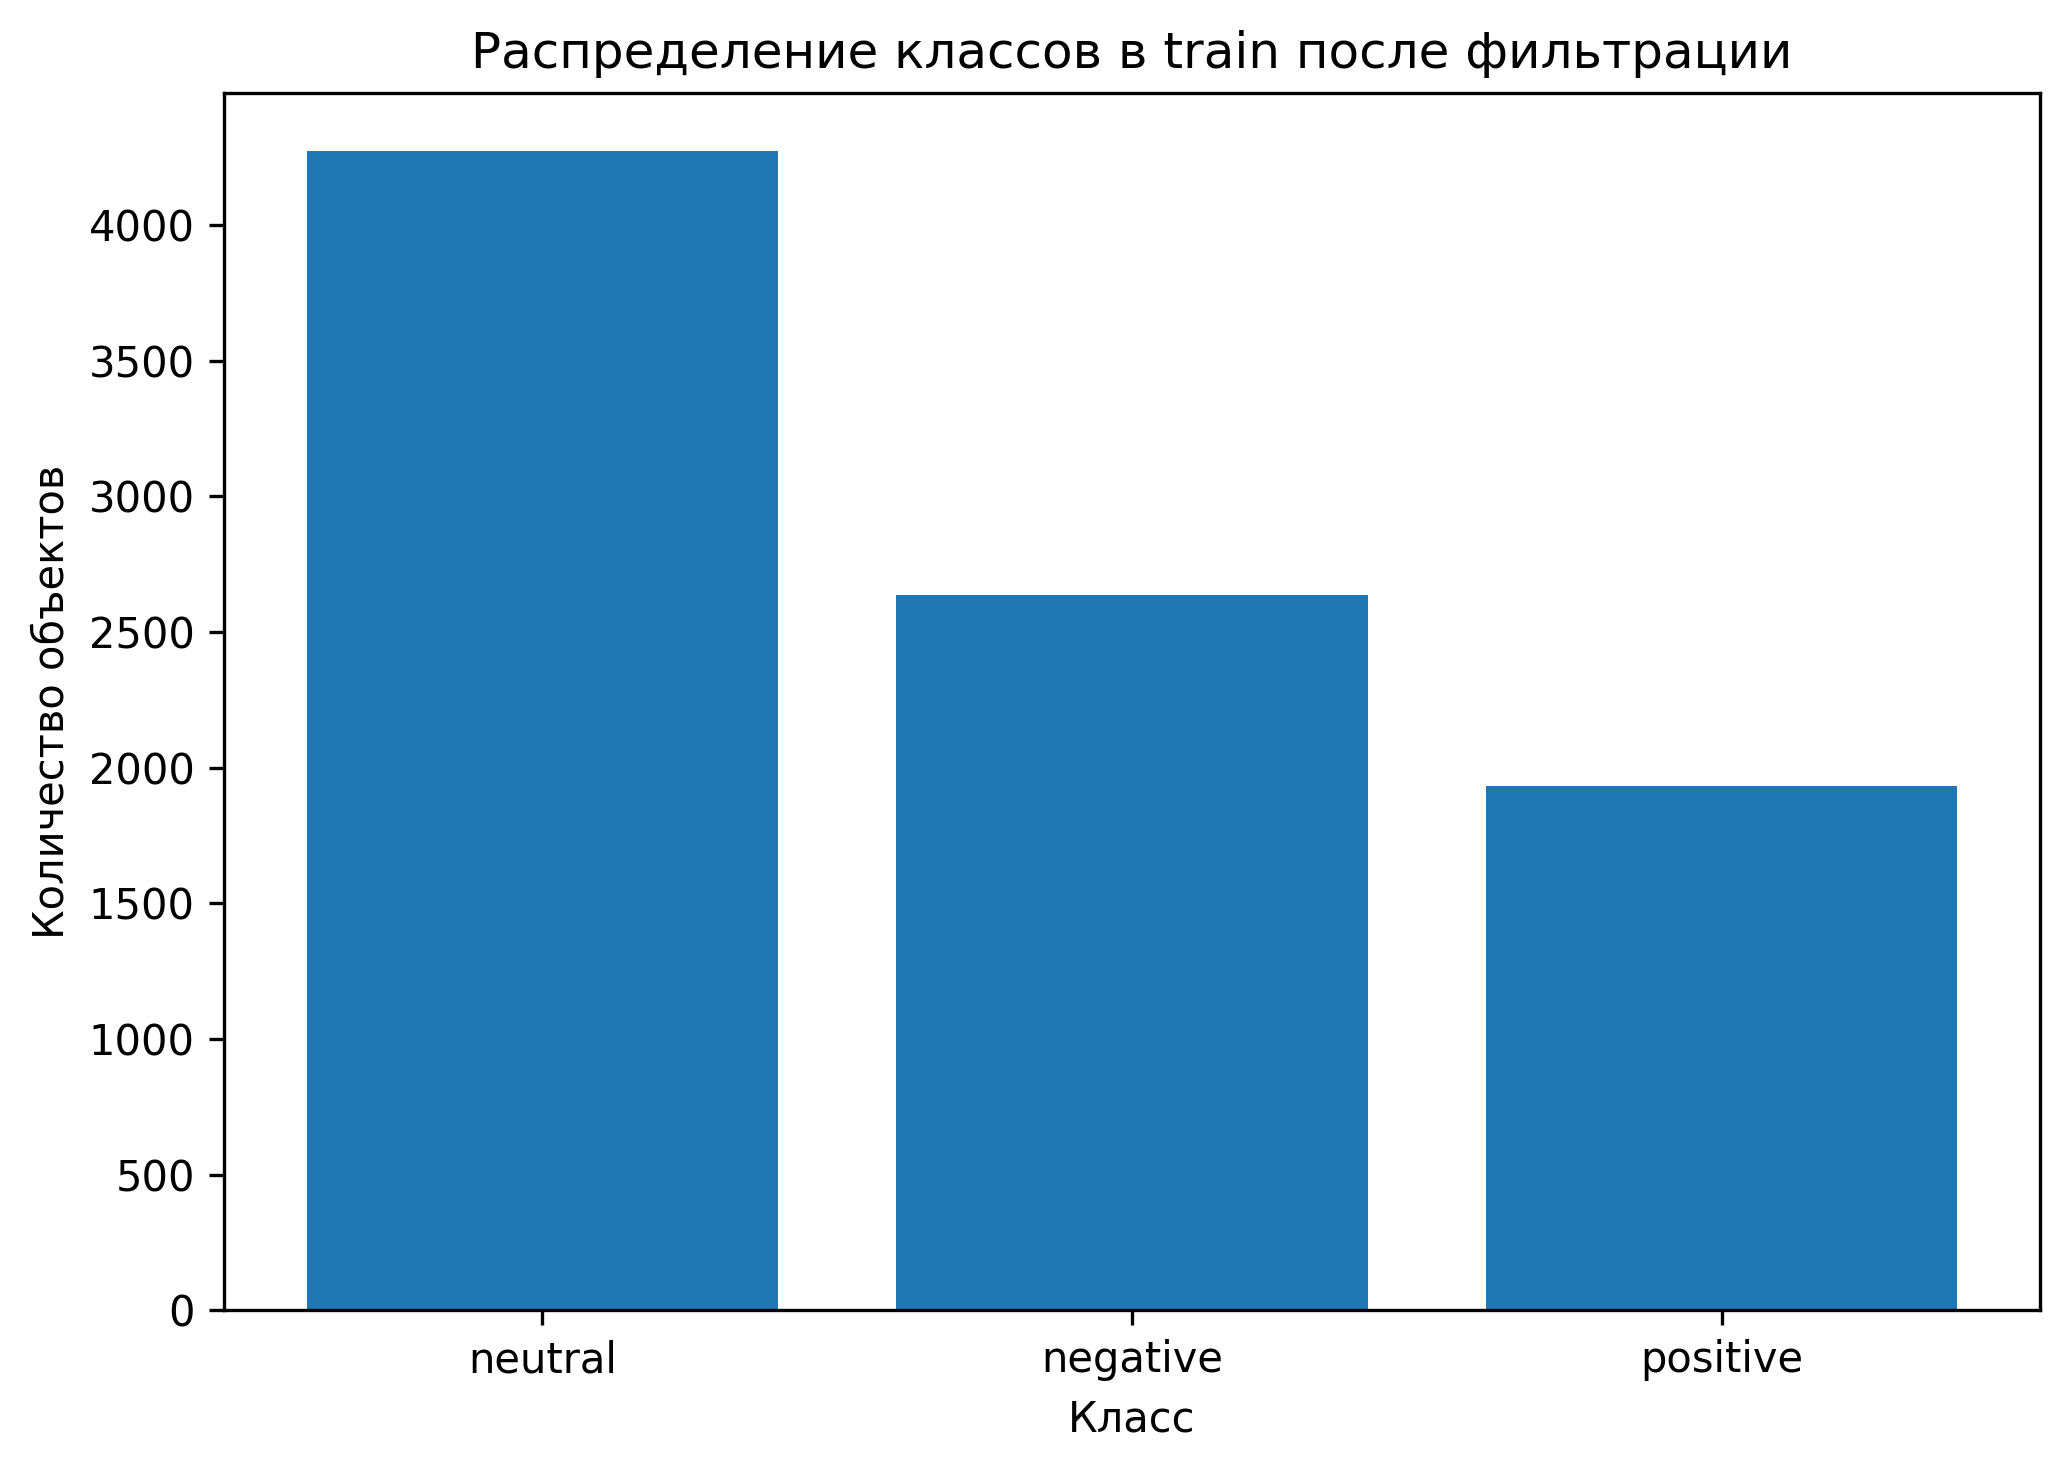

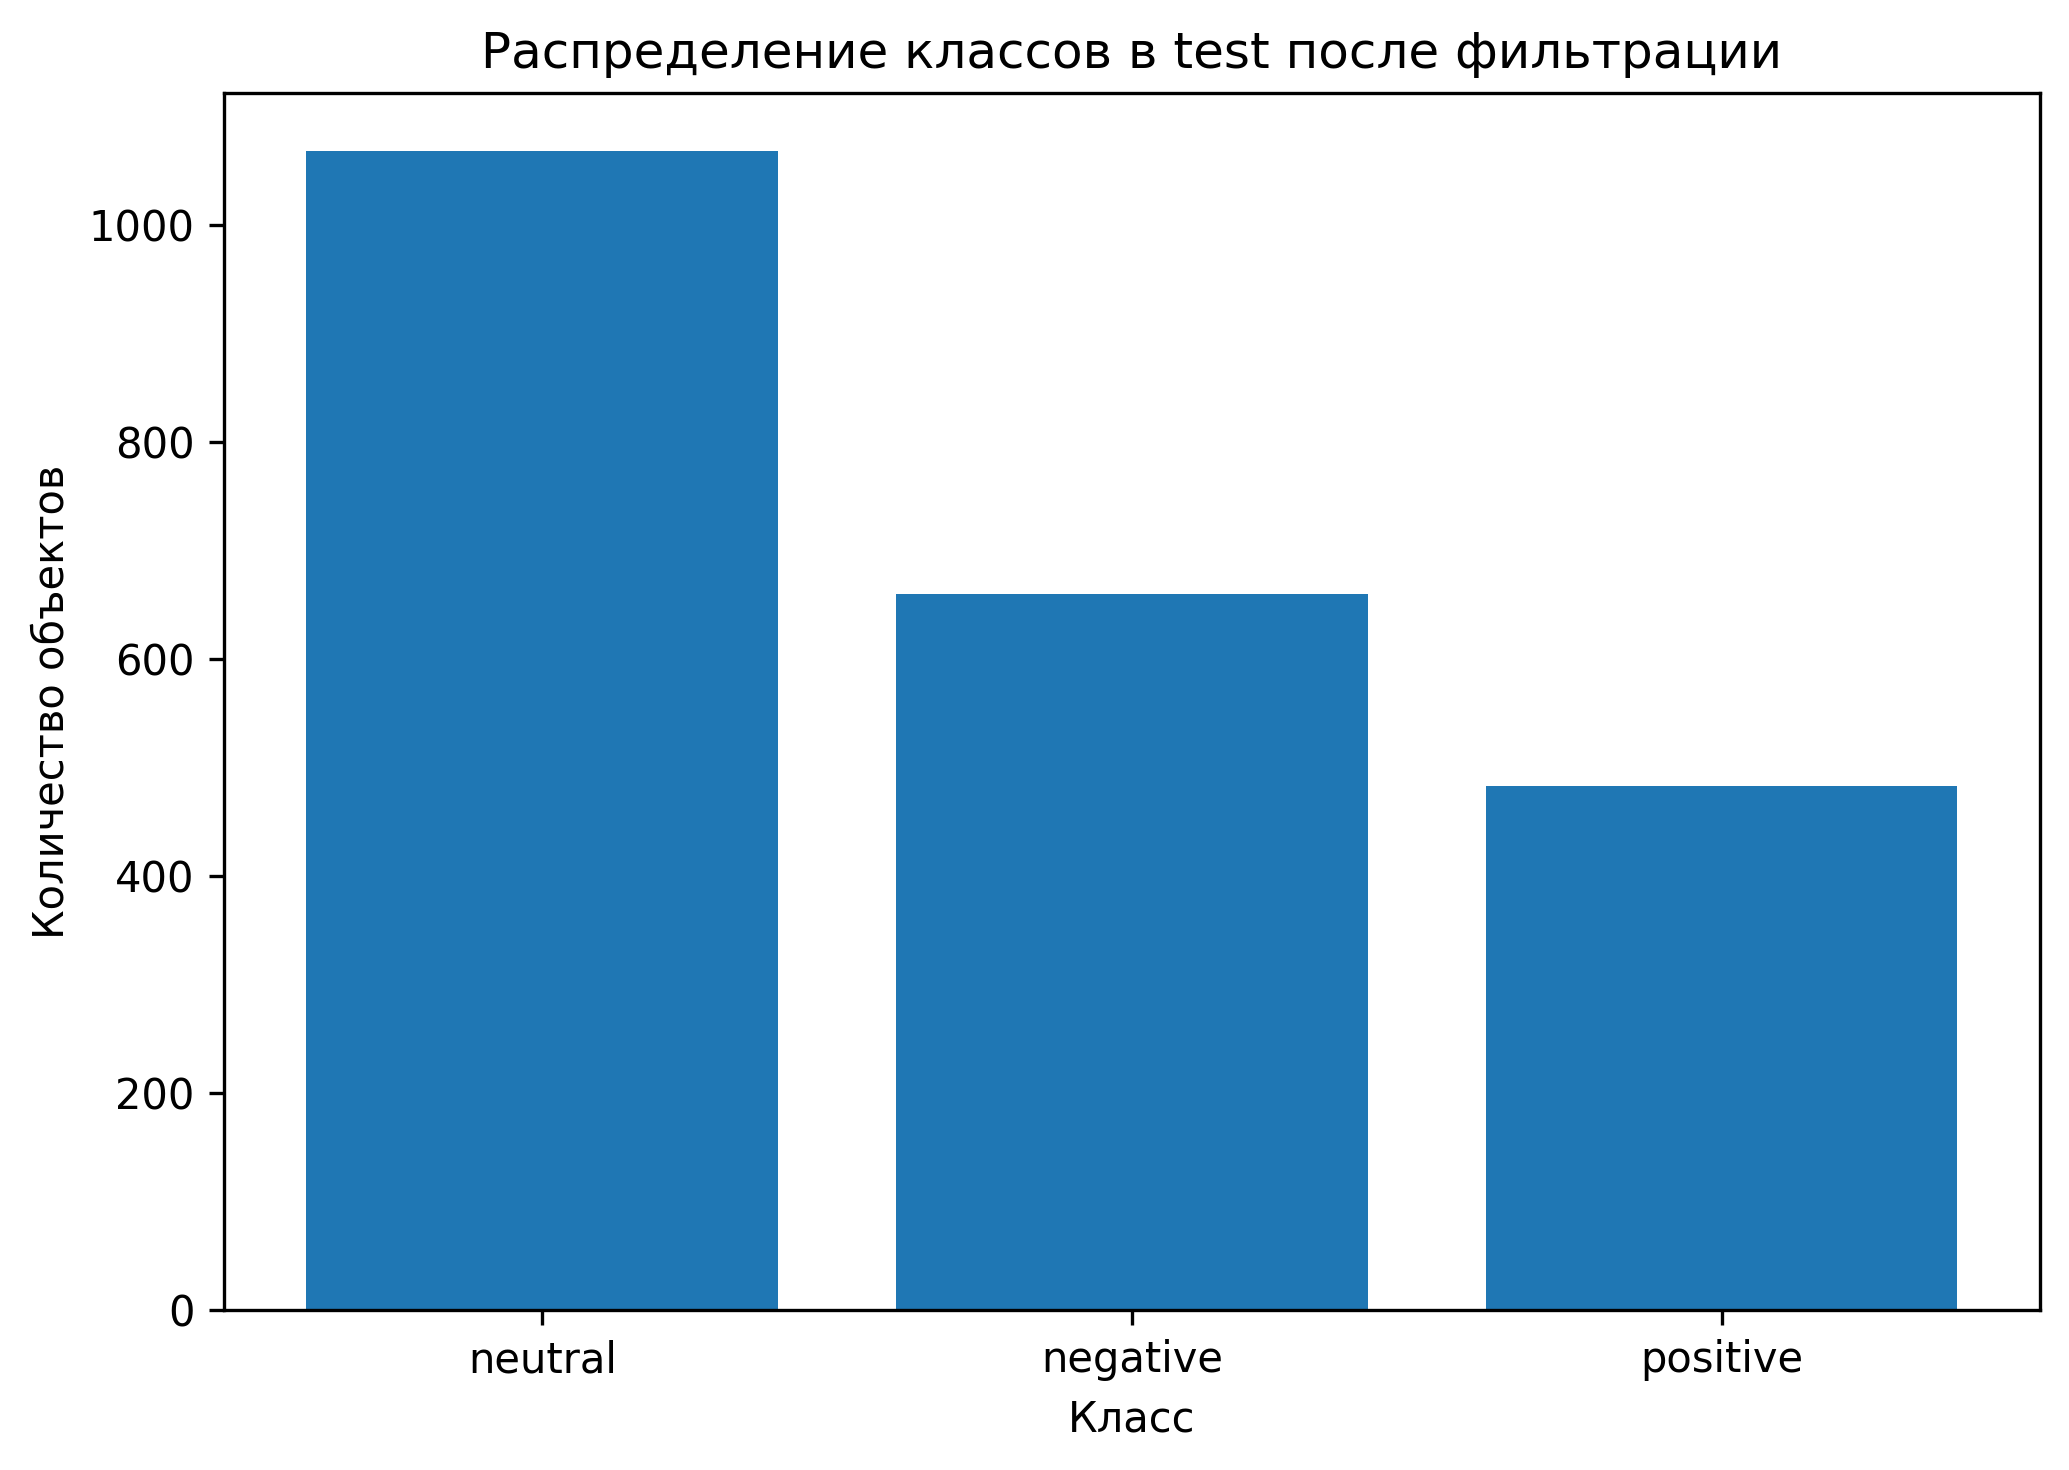

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5),dpi=300)
plt.bar(train_class_distribution["label"], train_class_distribution["count"])
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в train после фильтрации")
plt.tight_layout()
plt.savefig(FIG_DIR / "train_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5),dpi=300)
plt.bar(test_class_distribution["label"], test_class_distribution["count"])
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в test после фильтрации")
plt.tight_layout()
plt.savefig(FIG_DIR / "test_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Разделение обучающей выборки на train_final и val_final

In [17]:
from sklearn.model_selection import train_test_split

train_final_df, val_final_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["label"]
)

print("train_df shape:", train_df.shape)
print("train_final_df shape:", train_final_df.shape)
print("val_final_df shape:", val_final_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (8842, 3)
train_final_df shape: (7957, 3)
val_final_df shape: (885, 3)
test_df shape: (2211, 3)


In [18]:
print("Train_final class counts:")
print(train_final_df["label"].value_counts())

print("\nVal_final class counts:")
print(val_final_df["label"].value_counts())

print("\nTest_final class counts:")
print(test_df["label"].value_counts())

Train_final class counts:
label
neutral     3845
negative    2374
positive    1738
Name: count, dtype: int64

Val_final class counts:
label
neutral     428
negative    264
positive    193
Name: count, dtype: int64

Test_final class counts:
label
neutral     1068
negative     660
positive     483
Name: count, dtype: int64


In [19]:
print("Train_final class shares:")
print(train_final_df["label"].value_counts(normalize=True))

print("\nVal_final class shares:")
print(val_final_df["label"].value_counts(normalize=True))

print("\nTest_final class shares:")
print(test_df["label"].value_counts(normalize=True))

Train_final class shares:
label
neutral     0.483222
negative    0.298354
positive    0.218424
Name: proportion, dtype: float64

Val_final class shares:
label
neutral     0.483616
negative    0.298305
positive    0.218079
Name: proportion, dtype: float64

Test_final class shares:
label
neutral     0.483039
negative    0.298507
positive    0.218453
Name: proportion, dtype: float64


In [20]:
train_final_df.to_csv(TABLE_DIR / "train_final.csv", index=False, encoding="utf-8-sig")
val_final_df.to_csv(TABLE_DIR / "val_final.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(TABLE_DIR / "test_final.csv", index=False, encoding="utf-8-sig")

print("Saved:", TABLE_DIR / "train_final.csv")
print("Saved:", TABLE_DIR / "val_final.csv")
print("Saved:", TABLE_DIR / "test_final.csv")

Saved: e0_artifacts/tables/train_final.csv
Saved: e0_artifacts/tables/val_final.csv
Saved: e0_artifacts/tables/test_final.csv


In [21]:
split_info = f"""
E0 SPLIT DESCRIPTION

Source train shape after filtering: {train_df.shape}
Source test shape after filtering: {test_df.shape}

Split strategy:
- train_df split into train_final and val_final
- test_df kept unchanged as final test set

Random seed: {SEED}
Stratification: yes
Validation size from train_df: 0.1

Final shapes:
train_final_df: {train_final_df.shape}
val_final_df: {val_final_df.shape}
test_final_df: {test_df.shape}

Train_final class distribution:
{train_final_df['label'].value_counts().to_string()}

Val_final class distribution:
{val_final_df['label'].value_counts().to_string()}

Test_final class distribution:
{test_df['label'].value_counts().to_string()}
"""

with open(LOG_DIR / "data_split.txt", "w", encoding="utf-8") as f:
    f.write(split_info)

print("Saved:", LOG_DIR / "data_split.txt")

Saved: e0_artifacts/logs/data_split.txt


In [22]:
train_final_class_distribution = train_final_df["label"].value_counts().reset_index()
train_final_class_distribution.columns = ["label", "count"]
train_final_class_distribution["share"] = (
    train_final_class_distribution["count"] / train_final_class_distribution["count"].sum()
)

val_final_class_distribution = val_final_df["label"].value_counts().reset_index()
val_final_class_distribution.columns = ["label", "count"]
val_final_class_distribution["share"] = (
    val_final_class_distribution["count"] / val_final_class_distribution["count"].sum()
)

test_final_class_distribution = test_df["label"].value_counts().reset_index()
test_final_class_distribution.columns = ["label", "count"]
test_final_class_distribution["share"] = (
    test_final_class_distribution["count"] / test_final_class_distribution["count"].sum()
)

display(train_final_class_distribution)
display(val_final_class_distribution)
display(test_final_class_distribution)

,label,count,share
0,neutral,3845,0.483222
1,negative,2374,0.298354
2,positive,1738,0.218424


,label,count,share
0,neutral,428,0.483616
1,negative,264,0.298305
2,positive,193,0.218079


,label,count,share
0,neutral,1068,0.483039
1,negative,660,0.298507
2,positive,483,0.218453


In [23]:
train_final_class_distribution.to_csv(TABLE_DIR / "train_final_class_distribution.csv", index=False, encoding="utf-8-sig")
val_final_class_distribution.to_csv(TABLE_DIR / "val_final_class_distribution.csv", index=False, encoding="utf-8-sig")
test_final_class_distribution.to_csv(TABLE_DIR / "test_final_class_distribution.csv", index=False, encoding="utf-8-sig")

print("Saved:", TABLE_DIR / "train_final_class_distribution.csv")
print("Saved:", TABLE_DIR / "val_final_class_distribution.csv")
print("Saved:", TABLE_DIR / "test_final_class_distribution.csv")

Saved: e0_artifacts/tables/train_final_class_distribution.csv
Saved: e0_artifacts/tables/val_final_class_distribution.csv
Saved: e0_artifacts/tables/test_final_class_distribution.csv


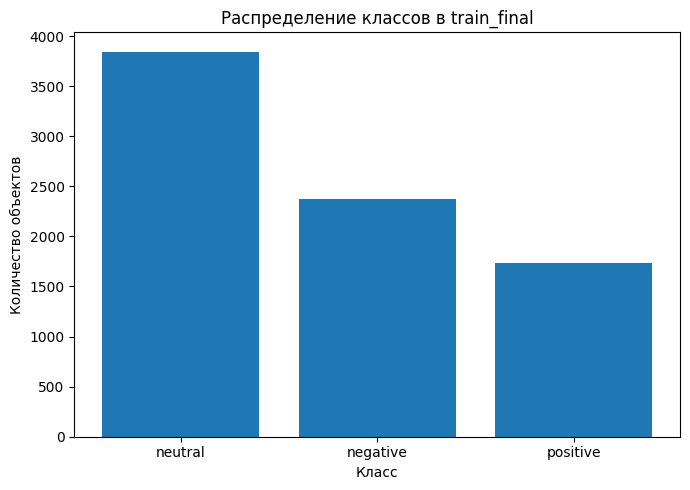

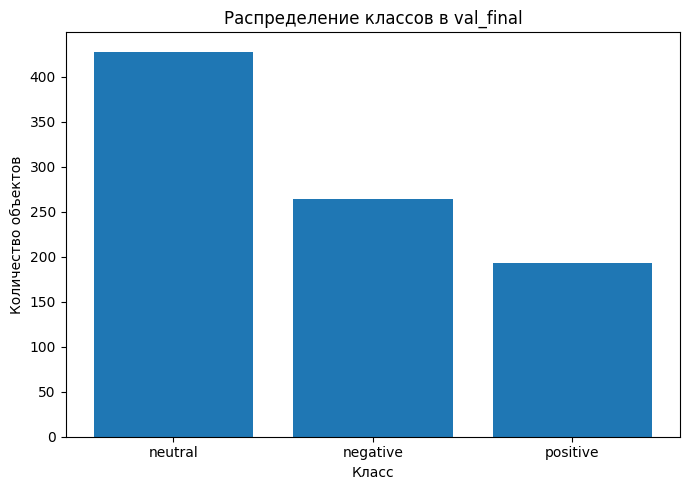

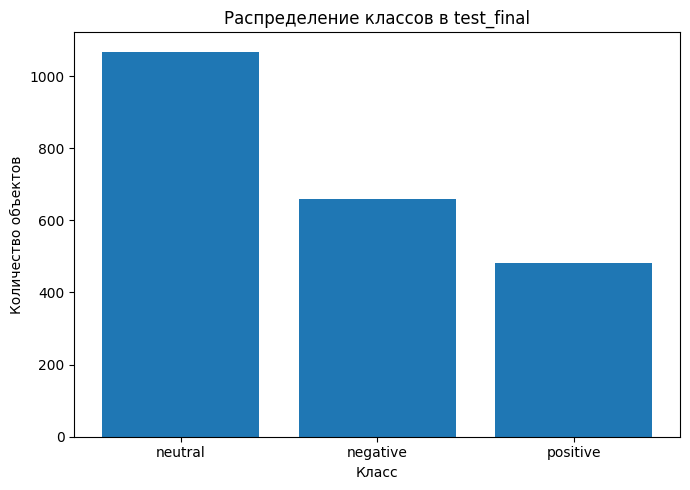

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.bar(train_final_class_distribution["label"], train_final_class_distribution["count"])
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в train_final")
plt.tight_layout()
plt.savefig(FIG_DIR / "train_final_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(val_final_class_distribution["label"], val_final_class_distribution["count"])
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в val_final")
plt.tight_layout()
plt.savefig(FIG_DIR / "val_final_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(test_final_class_distribution["label"], test_final_class_distribution["count"])
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в test_final")
plt.tight_layout()
plt.savefig(FIG_DIR / "test_final_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Итог

- test выборка не изменялась и используется как final test set;
- train выборка разделена на train_final и val_final;
- разбиение выполнено стратифицированно с random_state = 42;
- полученные части сохранены для дальнейшего воспроизводимого использования.

## 3. Подготовка данных для моделей и фиксация preprocessing

In [25]:
X_train = train_final_df["text"].copy()
y_train = train_final_df["label"].copy()

X_val = val_final_df["text"].copy()
y_val = val_final_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_val: (885,)
y_val: (885,)
X_test: (2211,)
y_test: (2211,)


In [26]:
CLASSICAL_PREPROCESSING_CONFIG = {
    "explicit_cleaning_function": False,
    "duplicate_removal": "done earlier by text",
    "used_columns": ["text", "label"],
    "target_classes": ["negative", "neutral", "positive"],
    "note": "texts are passed directly to TfidfVectorizer without separate clean_text()"
}

print(CLASSICAL_PREPROCESSING_CONFIG)

{'explicit_cleaning_function': False, 'duplicate_removal': 'done earlier by text', 'used_columns': ['text', 'label'], 'target_classes': ['negative', 'neutral', 'positive'], 'note': 'texts are passed directly to TfidfVectorizer without separate clean_text()'}


In [27]:
TFIDF_CONFIG = {
    "lowercase": True,
    "analyzer": "word",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "max_features": None
}

print(TFIDF_CONFIG)

{'lowercase': True, 'analyzer': 'word', 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'max_features': None}


In [28]:
CLASSICAL_MODELS_CONFIG = {
    "DummyClassifier": {
        "strategy": "most_frequent"
    },
    "MultinomialNB": {},
    "LogisticRegression": {
        "max_iter": 1000,
        "random_state": SEED
    },
    "LinearSVC": {
        "random_state": SEED
    }
}

print(CLASSICAL_MODELS_CONFIG)

{'DummyClassifier': {'strategy': 'most_frequent'}, 'MultinomialNB': {}, 'LogisticRegression': {'max_iter': 1000, 'random_state': 42}, 'LinearSVC': {'random_state': 42}}


In [29]:
LABEL2ID = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

BERT_COMMON_CONFIG = {
    "model_name": "cointegrated/rubert-tiny2",
    "tokenizer_name": "cointegrated/rubert-tiny2",
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
    "padding": "max_length",
    "truncation": True,
    "max_length": 128
}

BERT_BASELINE_CONFIG = {
    "num_train_epochs": 2,
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "weight_decay": 0.01,
    "logging_steps": 100,
    "metric_for_best_model": "f1_weighted",
    "greater_is_better": True,
    "fp16": False if device == "cpu" else True
}

BERT_TUNED_CONFIG = {
    "num_train_epochs": 3,
    "learning_rate": 3e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "weight_decay": 0.01,
    "logging_steps": 100,
    "metric_for_best_model": "f1_weighted",
    "greater_is_better": True,
    "fp16": False if device == "cpu" else True
}

print(BERT_COMMON_CONFIG)
print(BERT_BASELINE_CONFIG)
print(BERT_TUNED_CONFIG)

{'model_name': 'cointegrated/rubert-tiny2', 'tokenizer_name': 'cointegrated/rubert-tiny2', 'label2id': {'negative': 0, 'neutral': 1, 'positive': 2}, 'id2label': {0: 'negative', 1: 'neutral', 2: 'positive'}, 'padding': 'max_length', 'truncation': True, 'max_length': 128}
{'num_train_epochs': 2, 'learning_rate': 2e-05, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 16, 'weight_decay': 0.01, 'logging_steps': 100, 'metric_for_best_model': 'f1_weighted', 'greater_is_better': True, 'fp16': True}
{'num_train_epochs': 3, 'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 16, 'weight_decay': 0.01, 'logging_steps': 100, 'metric_for_best_model': 'f1_weighted', 'greater_is_better': True, 'fp16': True}


In [30]:
preprocessing_and_params_text = f"""
E0 PREPROCESSING AND PARAMETERS

DATA SPLITS USED:
- train_final_df
- val_final_df
- test_df

CLASSICAL PREPROCESSING CONFIG:
{CLASSICAL_PREPROCESSING_CONFIG}

TF-IDF CONFIG:
{TFIDF_CONFIG}

CLASSICAL MODELS CONFIG:
{CLASSICAL_MODELS_CONFIG}

BERT COMMON CONFIG:
{BERT_COMMON_CONFIG}

BERT BASELINE CONFIG:
{BERT_BASELINE_CONFIG}

BERT TUNED CONFIG:
{BERT_TUNED_CONFIG}
"""

with open(LOG_DIR / "preprocessing_and_params.txt", "w", encoding="utf-8") as f:
    f.write(preprocessing_and_params_text)

print("Saved:", LOG_DIR / "preprocessing_and_params.txt")

Saved: e0_artifacts/logs/preprocessing_and_params.txt


In [31]:
import json

config_bundle = {
    "classical_preprocessing": CLASSICAL_PREPROCESSING_CONFIG,
    "tfidf_config": TFIDF_CONFIG,
    "classical_models_config": CLASSICAL_MODELS_CONFIG,
    "bert_common_config": BERT_COMMON_CONFIG,
    "bert_baseline_config": BERT_BASELINE_CONFIG,
    "bert_tuned_config": BERT_TUNED_CONFIG
}

with open(LOG_DIR / "preprocessing_and_params.json", "w", encoding="utf-8") as f:
    json.dump(config_bundle, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "preprocessing_and_params.json")

Saved: e0_artifacts/logs/preprocessing_and_params.json


## 4. Classical baseline: TF-IDF + Dummy / MNB / Logistic Regression / Linear SVM

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

baseline_results = []

X_train_tfidf shape: (7957, 8037)
X_test_tfidf shape: (2211, 8037)


In [33]:
import time
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [34]:
def evaluate_classical_model(model, model_name, X_train, y_train, X_test, y_test, report_path):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report = classification_report(y_test, y_pred, digits=4)
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report)

    result = {
        "model": model_name,
        "representation": "TF-IDF word (1,2)",
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "train_time_sec": round(train_time, 4),
        "seed": SEED,
        "notes": "classical baseline"
    }

    return result, y_pred, report

In [35]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_result, y_pred_dummy, report_dummy = evaluate_classical_model(
    model=dummy_model,
    model_name="DummyClassifier",
    X_train=X_train_tfidf,
    y_train=y_train,
    X_test=X_test_tfidf,
    y_test=y_test,
    report_path=REPORT_DIR / "classification_report_dummy.txt"
)

baseline_results.append(dummy_result)

print(dummy_result)
print(report_dummy)

{'model': 'DummyClassifier', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.483, 'precision_weighted': 0.2333, 'recall_weighted': 0.483, 'weighted_f1': 0.3147, 'macro_f1': 0.2171, 'train_time_sec': 0.0063, 'seed': 42, 'notes': 'classical baseline'}
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       660
     neutral     0.4830    1.0000    0.6514      1068
    positive     0.0000    0.0000    0.0000       483

    accuracy                         0.4830      2211
   macro avg     0.1610    0.3333    0.2171      2211
weighted avg     0.2333    0.4830    0.3147      2211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
from sklearn.naive_bayes import MultinomialNB

mnb_model = MultinomialNB()

mnb_result, y_pred_mnb, report_mnb = evaluate_classical_model(
    model=mnb_model,
    model_name="Multinomial Naive Bayes",
    X_train=X_train_tfidf,
    y_train=y_train,
    X_test=X_test_tfidf,
    y_test=y_test,
    report_path=REPORT_DIR / "classification_report_mnb.txt"
)

baseline_results.append(mnb_result)

print(mnb_result)
print(report_mnb)

{'model': 'Multinomial Naive Bayes', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.5929, 'precision_weighted': 0.6423, 'recall_weighted': 0.5929, 'weighted_f1': 0.5482, 'macro_f1': 0.4999, 'train_time_sec': 0.0133, 'seed': 42, 'notes': 'classical baseline'}
              precision    recall  f1-score   support

    negative     0.6338    0.3409    0.4433       660
     neutral     0.5668    0.9139    0.6996      1068
    positive     0.8209    0.2277    0.3566       483

    accuracy                         0.5929      2211
   macro avg     0.6738    0.4942    0.4999      2211
weighted avg     0.6423    0.5929    0.5482      2211



In [37]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, random_state=SEED)

logreg_result, y_pred_logreg, report_logreg = evaluate_classical_model(
    model=logreg_model,
    model_name="Logistic Regression",
    X_train=X_train_tfidf,
    y_train=y_train,
    X_test=X_test_tfidf,
    y_test=y_test,
    report_path=REPORT_DIR / "classification_report_logreg.txt"
)

baseline_results.append(logreg_result)

print(logreg_result)
print(report_logreg)

{'model': 'Logistic Regression', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6083, 'precision_weighted': 0.6183, 'recall_weighted': 0.6083, 'weighted_f1': 0.5888, 'macro_f1': 0.5546, 'train_time_sec': 0.8411, 'seed': 42, 'notes': 'classical baseline'}
              precision    recall  f1-score   support

    negative     0.5996    0.4652    0.5239       660
     neutral     0.5989    0.8221    0.6930      1068
    positive     0.6867    0.3313    0.4469       483

    accuracy                         0.6083      2211
   macro avg     0.6284    0.5395    0.5546      2211
weighted avg     0.6183    0.6083    0.5888      2211



In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=SEED)

svm_result, y_pred_svm, report_svm = evaluate_classical_model(
    model=svm_model,
    model_name="Linear SVM",
    X_train=X_train_tfidf,
    y_train=y_train,
    X_test=X_test_tfidf,
    y_test=y_test,
    report_path=REPORT_DIR / "classification_report_svm.txt"
)

baseline_results.append(svm_result)

print(svm_result)
print(report_svm)

{'model': 'Linear SVM', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6097, 'precision_weighted': 0.6057, 'recall_weighted': 0.6097, 'weighted_f1': 0.6011, 'macro_f1': 0.5737, 'train_time_sec': 0.1084, 'seed': 42, 'notes': 'classical baseline'}
              precision    recall  f1-score   support

    negative     0.5816    0.5182    0.5481       660
     neutral     0.6279    0.7537    0.6851      1068
    positive     0.5894    0.4161    0.4879       483

    accuracy                         0.6097      2211
   macro avg     0.5997    0.5627    0.5737      2211
weighted avg     0.6057    0.6097    0.6011      2211



In [39]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(baseline_results_df)

,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,notes
0,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1084,42,classical baseline
1,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,0.8411,42,classical baseline
2,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0133,42,classical baseline
3,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0063,42,classical baseline


In [40]:
baseline_results_df.to_csv(TABLE_DIR / "baseline_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "baseline_results.csv")

Saved: e0_artifacts/tables/baseline_results.csv


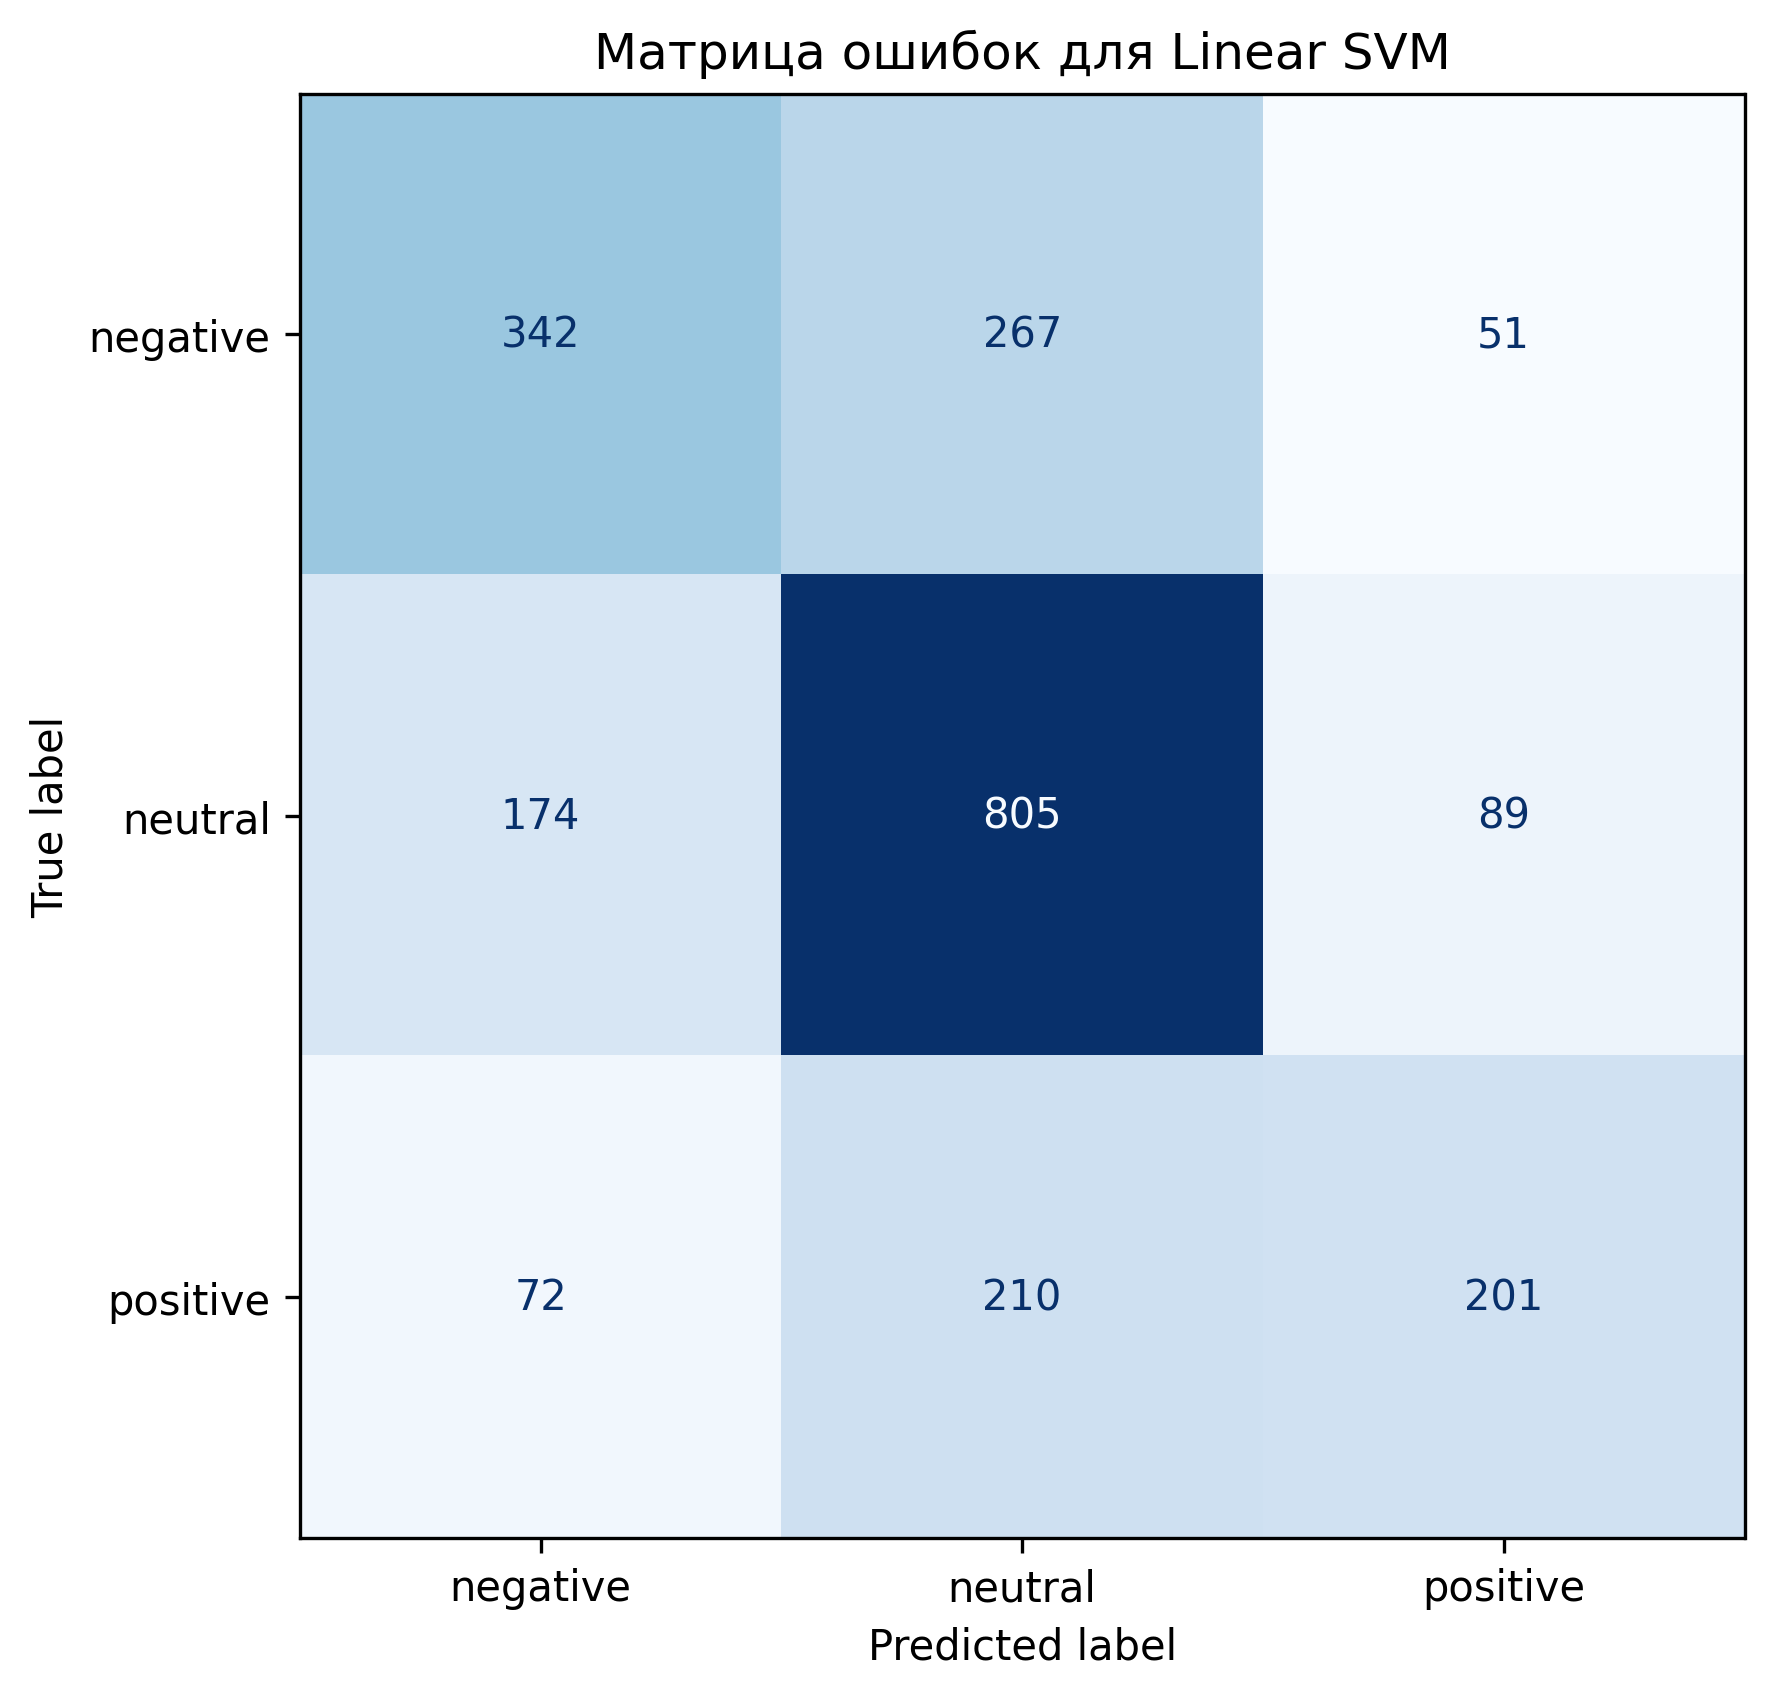

In [41]:
import matplotlib.pyplot as plt

labels_order = ["negative", "neutral", "positive"]

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels_order)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_svm.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для Linear SVM")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

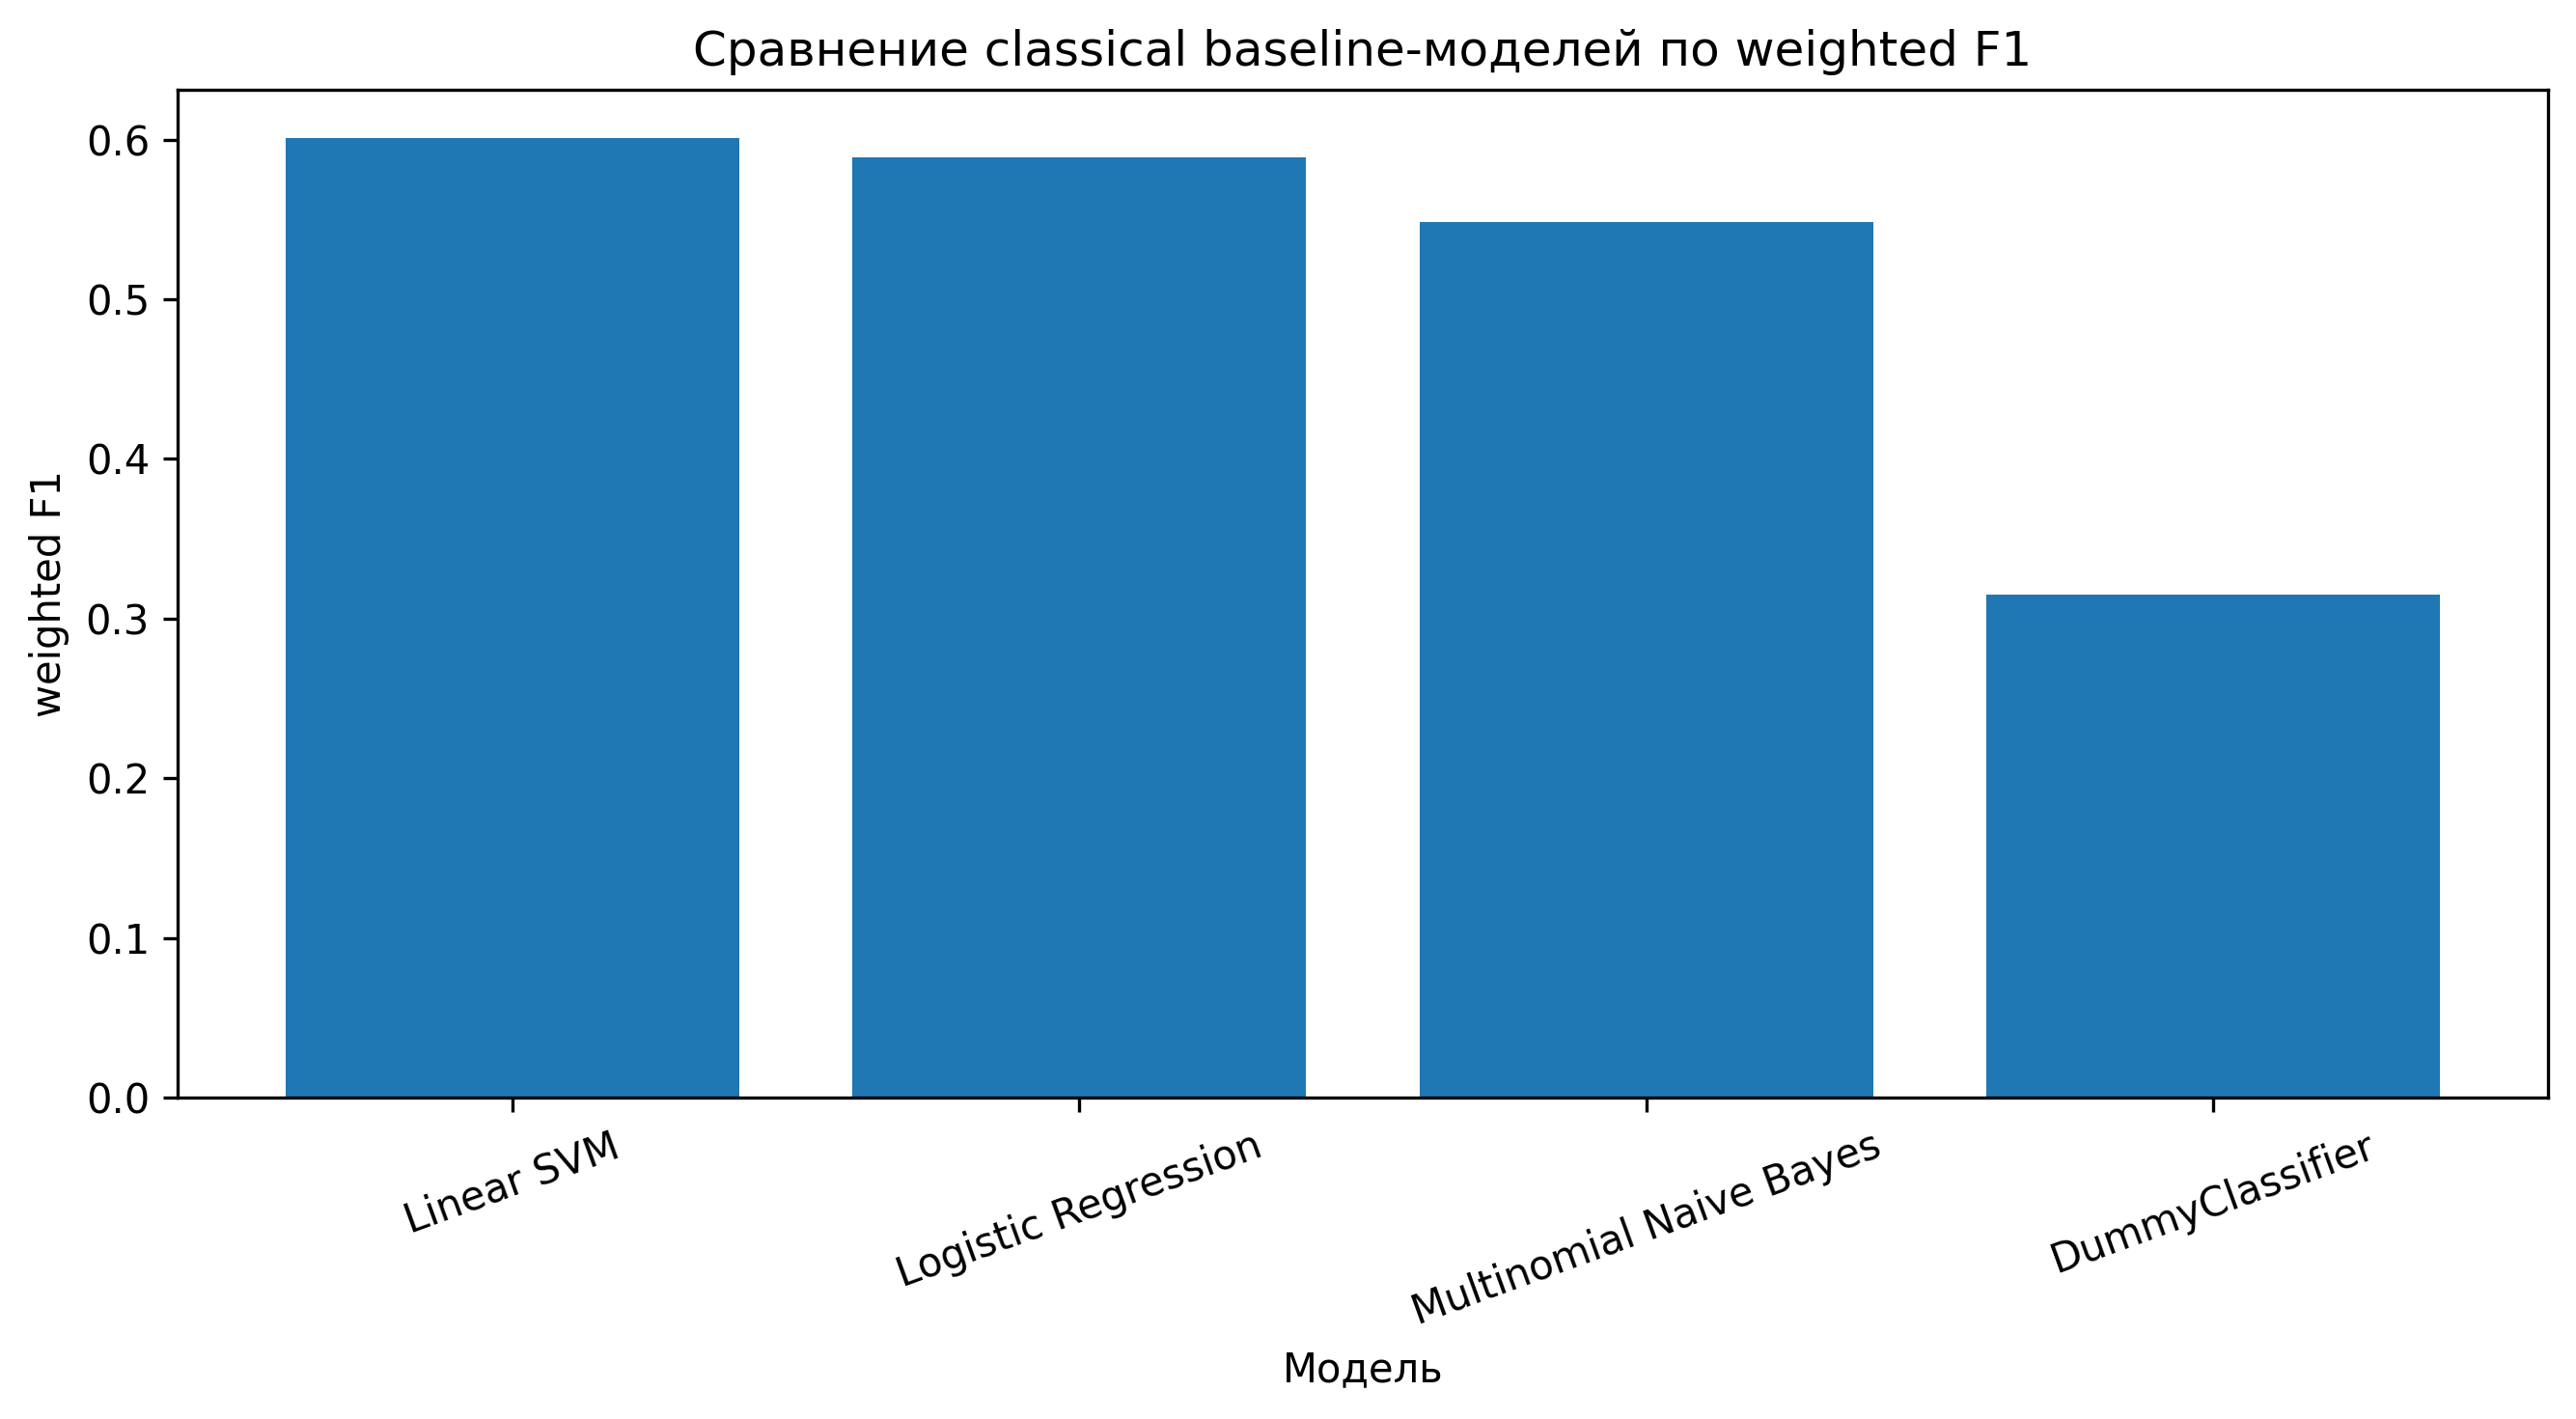

In [42]:
plot_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение classical baseline-моделей по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

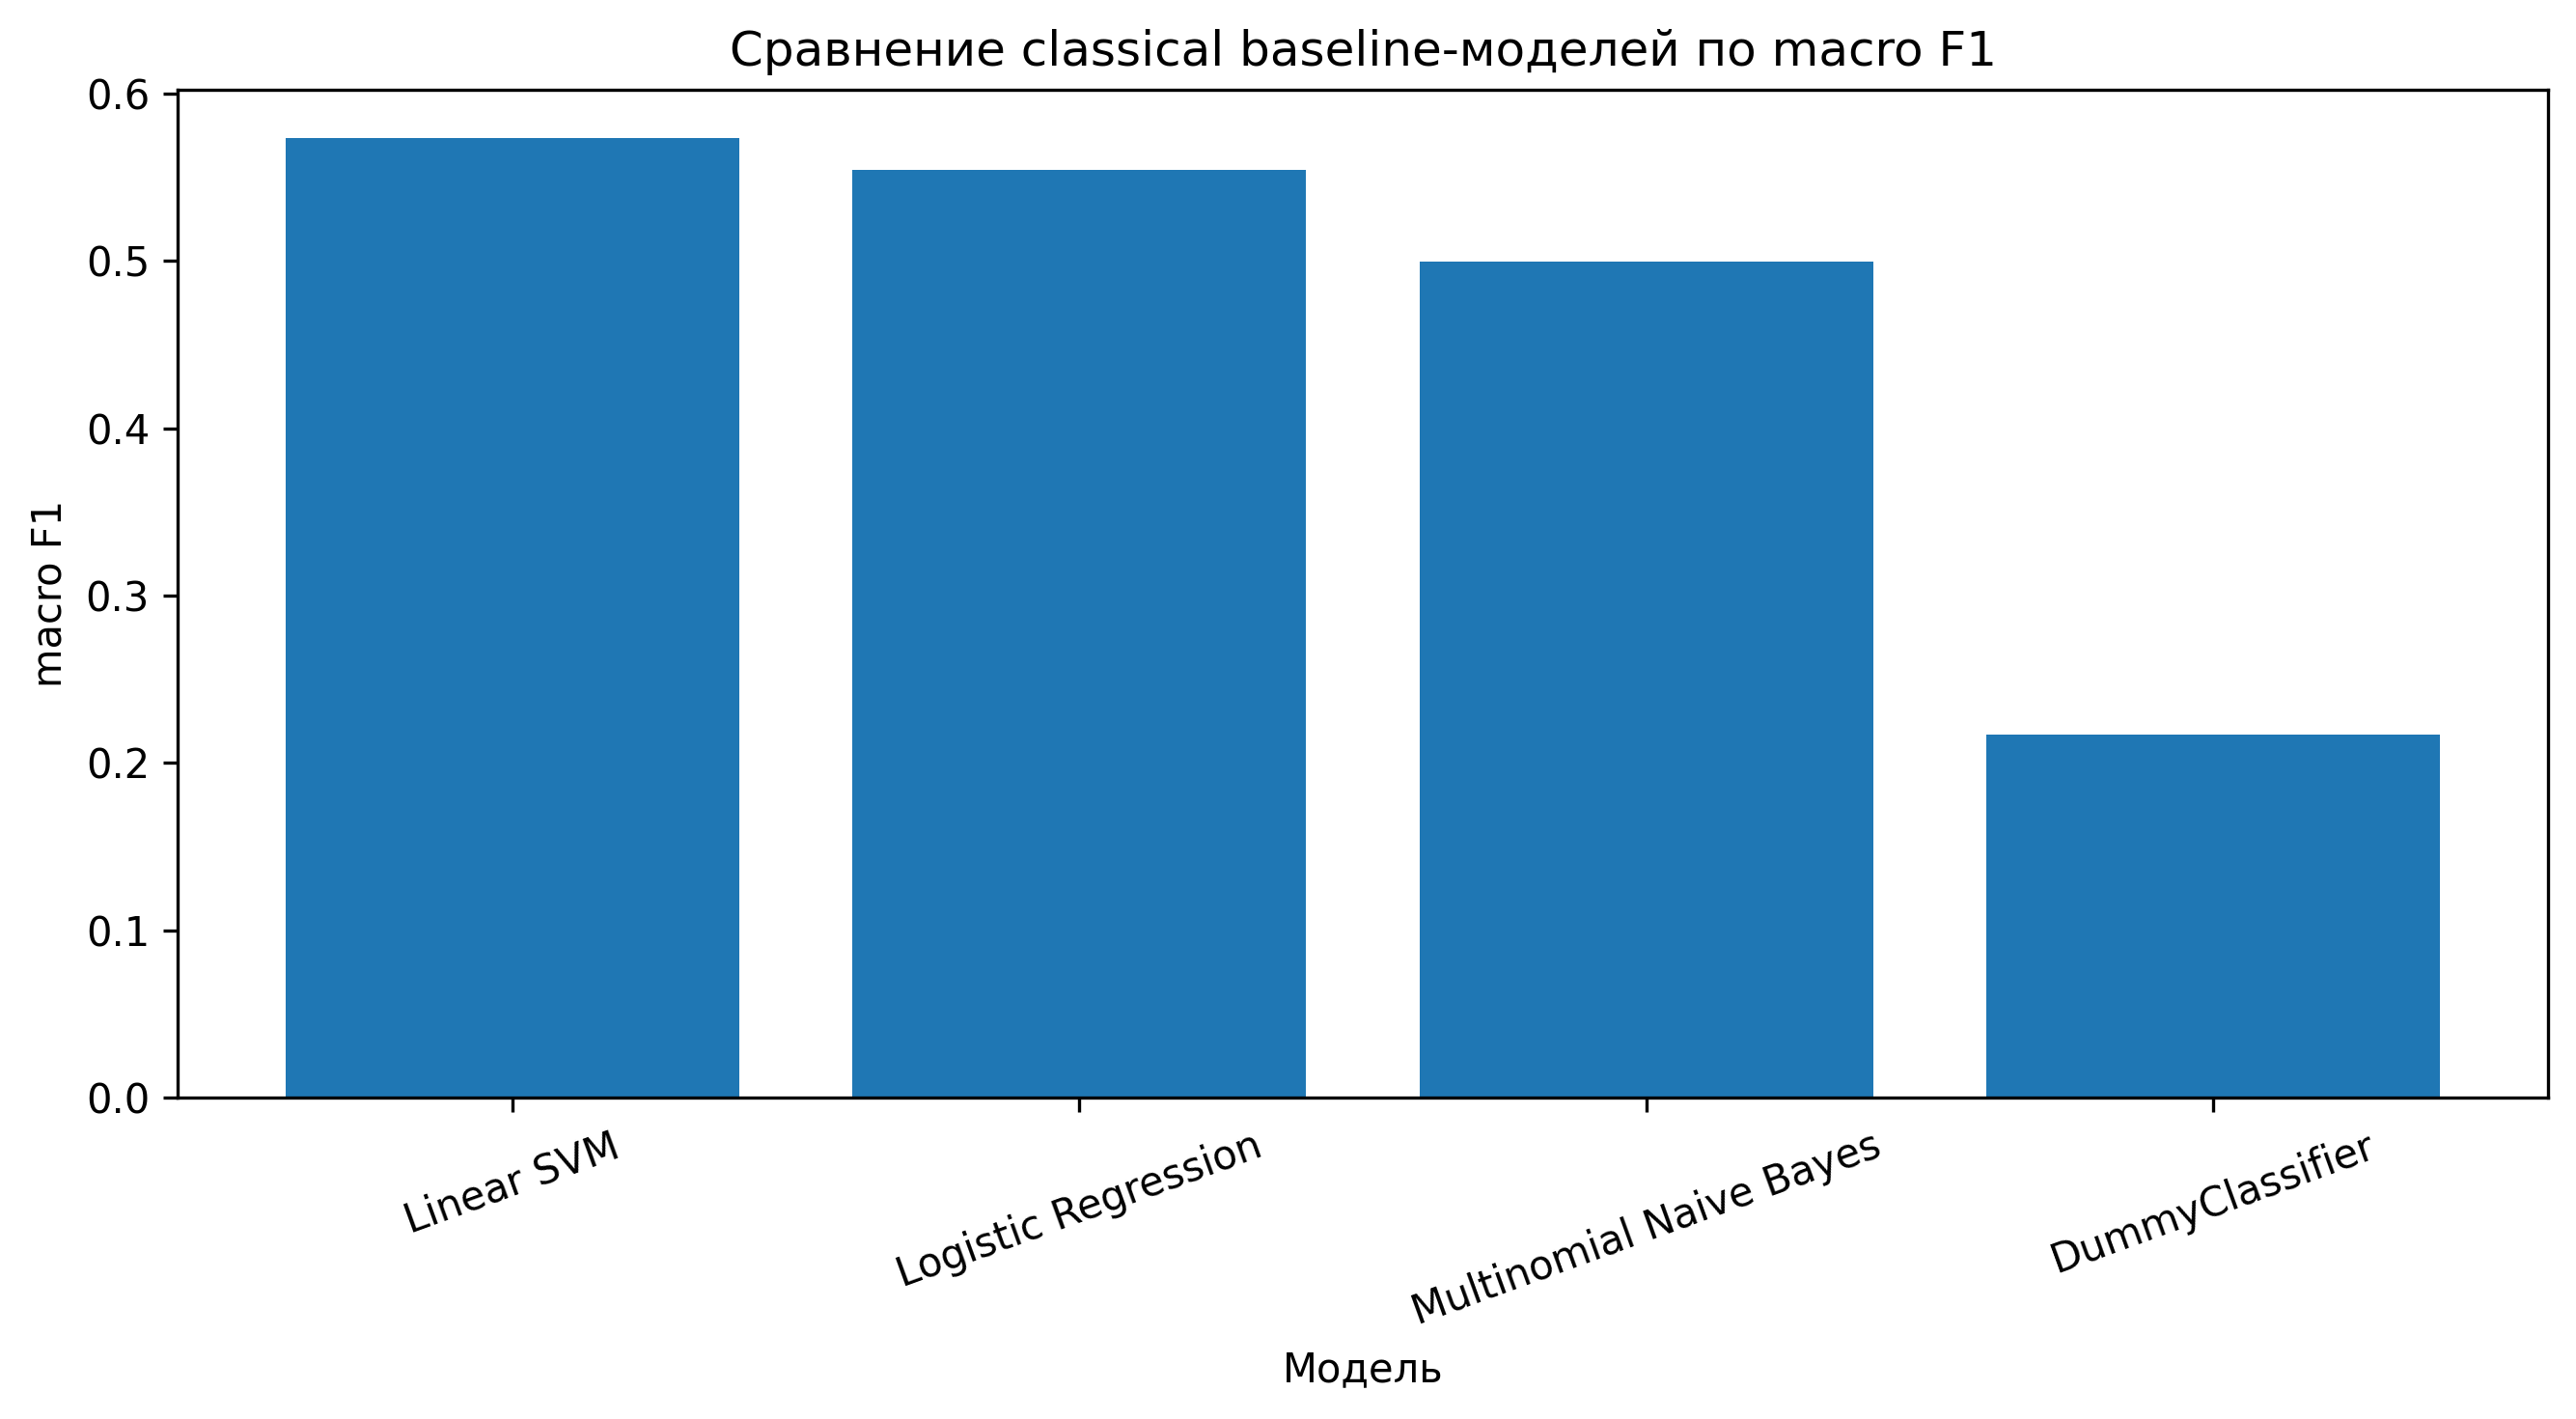

In [43]:
plot_df_macro = baseline_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение classical baseline-моделей по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
classical_summary = f"""
E0 CLASSICAL BASELINE SUMMARY

Vectorizer:
{TFIDF_CONFIG}

Models:
- DummyClassifier
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM

Results:
{baseline_results_df.to_string(index=False)}
"""

with open(LOG_DIR / "classical_baseline_summary.txt", "w", encoding="utf-8") as f:
    f.write(classical_summary)

print("Saved:", LOG_DIR / "classical_baseline_summary.txt")

Saved: e0_artifacts/logs/classical_baseline_summary.txt


In [45]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 5. Transformer baseline: ruBERT-tiny2

In [46]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [47]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

CUDA available: True
GPU: Tesla T4
Device: cuda


In [48]:
train_hf = train_final_df.copy()
val_hf = val_final_df.copy()
test_hf = test_df.copy()

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
id2label = {v: k for k, v in label2id.items()}

train_hf["label_id"] = train_hf["label"].map(label2id)
val_hf["label_id"] = val_hf["label"].map(label2id)
test_hf["label_id"] = test_hf["label"].map(label2id)

display(train_hf.head())
display(val_hf.head())
display(test_hf.head())

,text,label,id,label_id
8754,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501,1
603,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352,2
9180,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569,1
7318,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912,1
1606,сижу в такси рядом ползает паук няшка,positive,1276191130535821315,2


,text,label,id,label_id
7275,Да его надо скачать хотя бы потому что там ест...,neutral,1283293286799638529,1
529,@suckerforhome блин..сочувствую.,negative,1269992603543572482,0
3969,@stayloveswoojin Дыня,neutral,1285265175898140674,1
4980,@polinapingvina @Teimir1 личный опыт субъектив...,neutral,1299732127307755523,1
5336,@deadjane666 Подъезжаешь к ней на фиолетовом з...,positive,1237272095647764480,2


,text,label,id,label_id
1,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576,2
2,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136,2
4,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209,1
5,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432,0
6,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041,2


In [49]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_hf[["text", "label_id"]])
val_dataset = Dataset.from_pandas(val_hf[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_hf[["text", "label_id"]])

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 7957
})
Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 885
})
Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 2211
})


In [50]:
model_name = "cointegrated/rubert-tiny2"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [51]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7957 [00:00<?, ? examples/s]

Map:   0%|          | 0/885 [00:00<?, ? examples/s]

Map:   0%|          | 0/2211 [00:00<?, ? examples/s]

In [52]:
train_tokenized = train_tokenized.rename_column("label_id", "labels")
val_tokenized = val_tokenized.rename_column("label_id", "labels")
test_tokenized = test_tokenized.rename_column("label_id", "labels")

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

In [53]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

In [54]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    precision_w = precision_metric.compute(predictions=preds, references=labels, average="weighted")["precision"]
    recall_w = recall_metric.compute(predictions=preds, references=labels, average="weighted")["recall"]
    f1_w = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    f1_m = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "f1_macro": f1_m
    }

In [55]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./rubert_tiny_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True if device == "cuda" else False
)

In [56]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

In [57]:
import time

start_time = time.time()
trainer.train()
train_time_bert = time.time() - start_time

print("BERT baseline train time (s):", round(train_time_bert, 4))

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.847004,0.767537,0.684746,0.689762,0.684746,0.677898,0.656939
2,0.742012,0.728648,0.675706,0.673958,0.675706,0.673218,0.655157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

BERT baseline train time (s): 46.0276


In [58]:
eval_results_val = trainer.evaluate(eval_dataset=val_tokenized)
print(eval_results_val)

{'eval_loss': 0.7672982811927795, 'eval_accuracy': 0.6858757062146893, 'eval_precision_weighted': 0.6907980593233046, 'eval_recall_weighted': 0.6858757062146893, 'eval_f1_weighted': 0.6790674049146314, 'eval_f1_macro': 0.6580836001853055, 'eval_runtime': 0.8977, 'eval_samples_per_second': 985.853, 'eval_steps_per_second': 62.382, 'epoch': 2.0}


In [59]:
pred_output = trainer.predict(test_tokenized)

y_pred_bert = np.argmax(pred_output.predictions, axis=-1)
y_true_bert = pred_output.label_ids

print("Pred shape:", y_pred_bert.shape)
print("True shape:", y_true_bert.shape)

Pred shape: (2211,)
True shape: (2211,)


In [60]:
from sklearn.metrics import classification_report

label_names = ["negative", "neutral", "positive"]

report_bert = classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_names,
    digits=4
)

print(report_bert)

with open(REPORT_DIR / "classification_report_rubert_tiny2.txt", "w", encoding="utf-8") as f:
    f.write(report_bert)

print("Saved:", REPORT_DIR / "classification_report_rubert_tiny2.txt")

              precision    recall  f1-score   support

    negative     0.6581    0.5803    0.6167       660
     neutral     0.6635    0.8549    0.7471      1068
    positive     0.7747    0.4058    0.5326       483

    accuracy                         0.6748      2211
   macro avg     0.6988    0.6137    0.6322      2211
weighted avg     0.6862    0.6748    0.6613      2211

Saved: e0_artifacts/reports/classification_report_rubert_tiny2.txt


In [61]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

acc_bert = accuracy_score(y_true_bert, y_pred_bert)
precision_w_bert, recall_w_bert, f1_w_bert, _ = precision_recall_fscore_support(
    y_true_bert, y_pred_bert, average="weighted", zero_division=0
)
f1_macro_bert = f1_score(y_true_bert, y_pred_bert, average="macro")

print("Test accuracy:", round(acc_bert, 4))
print("Test precision_weighted:", round(precision_w_bert, 4))
print("Test recall_weighted:", round(recall_w_bert, 4))
print("Test weighted_f1:", round(f1_w_bert, 4))
print("Test macro_f1:", round(f1_macro_bert, 4))

Test accuracy: 0.6748
Test precision_weighted: 0.6862
Test recall_weighted: 0.6748
Test weighted_f1: 0.6613
Test macro_f1: 0.6322


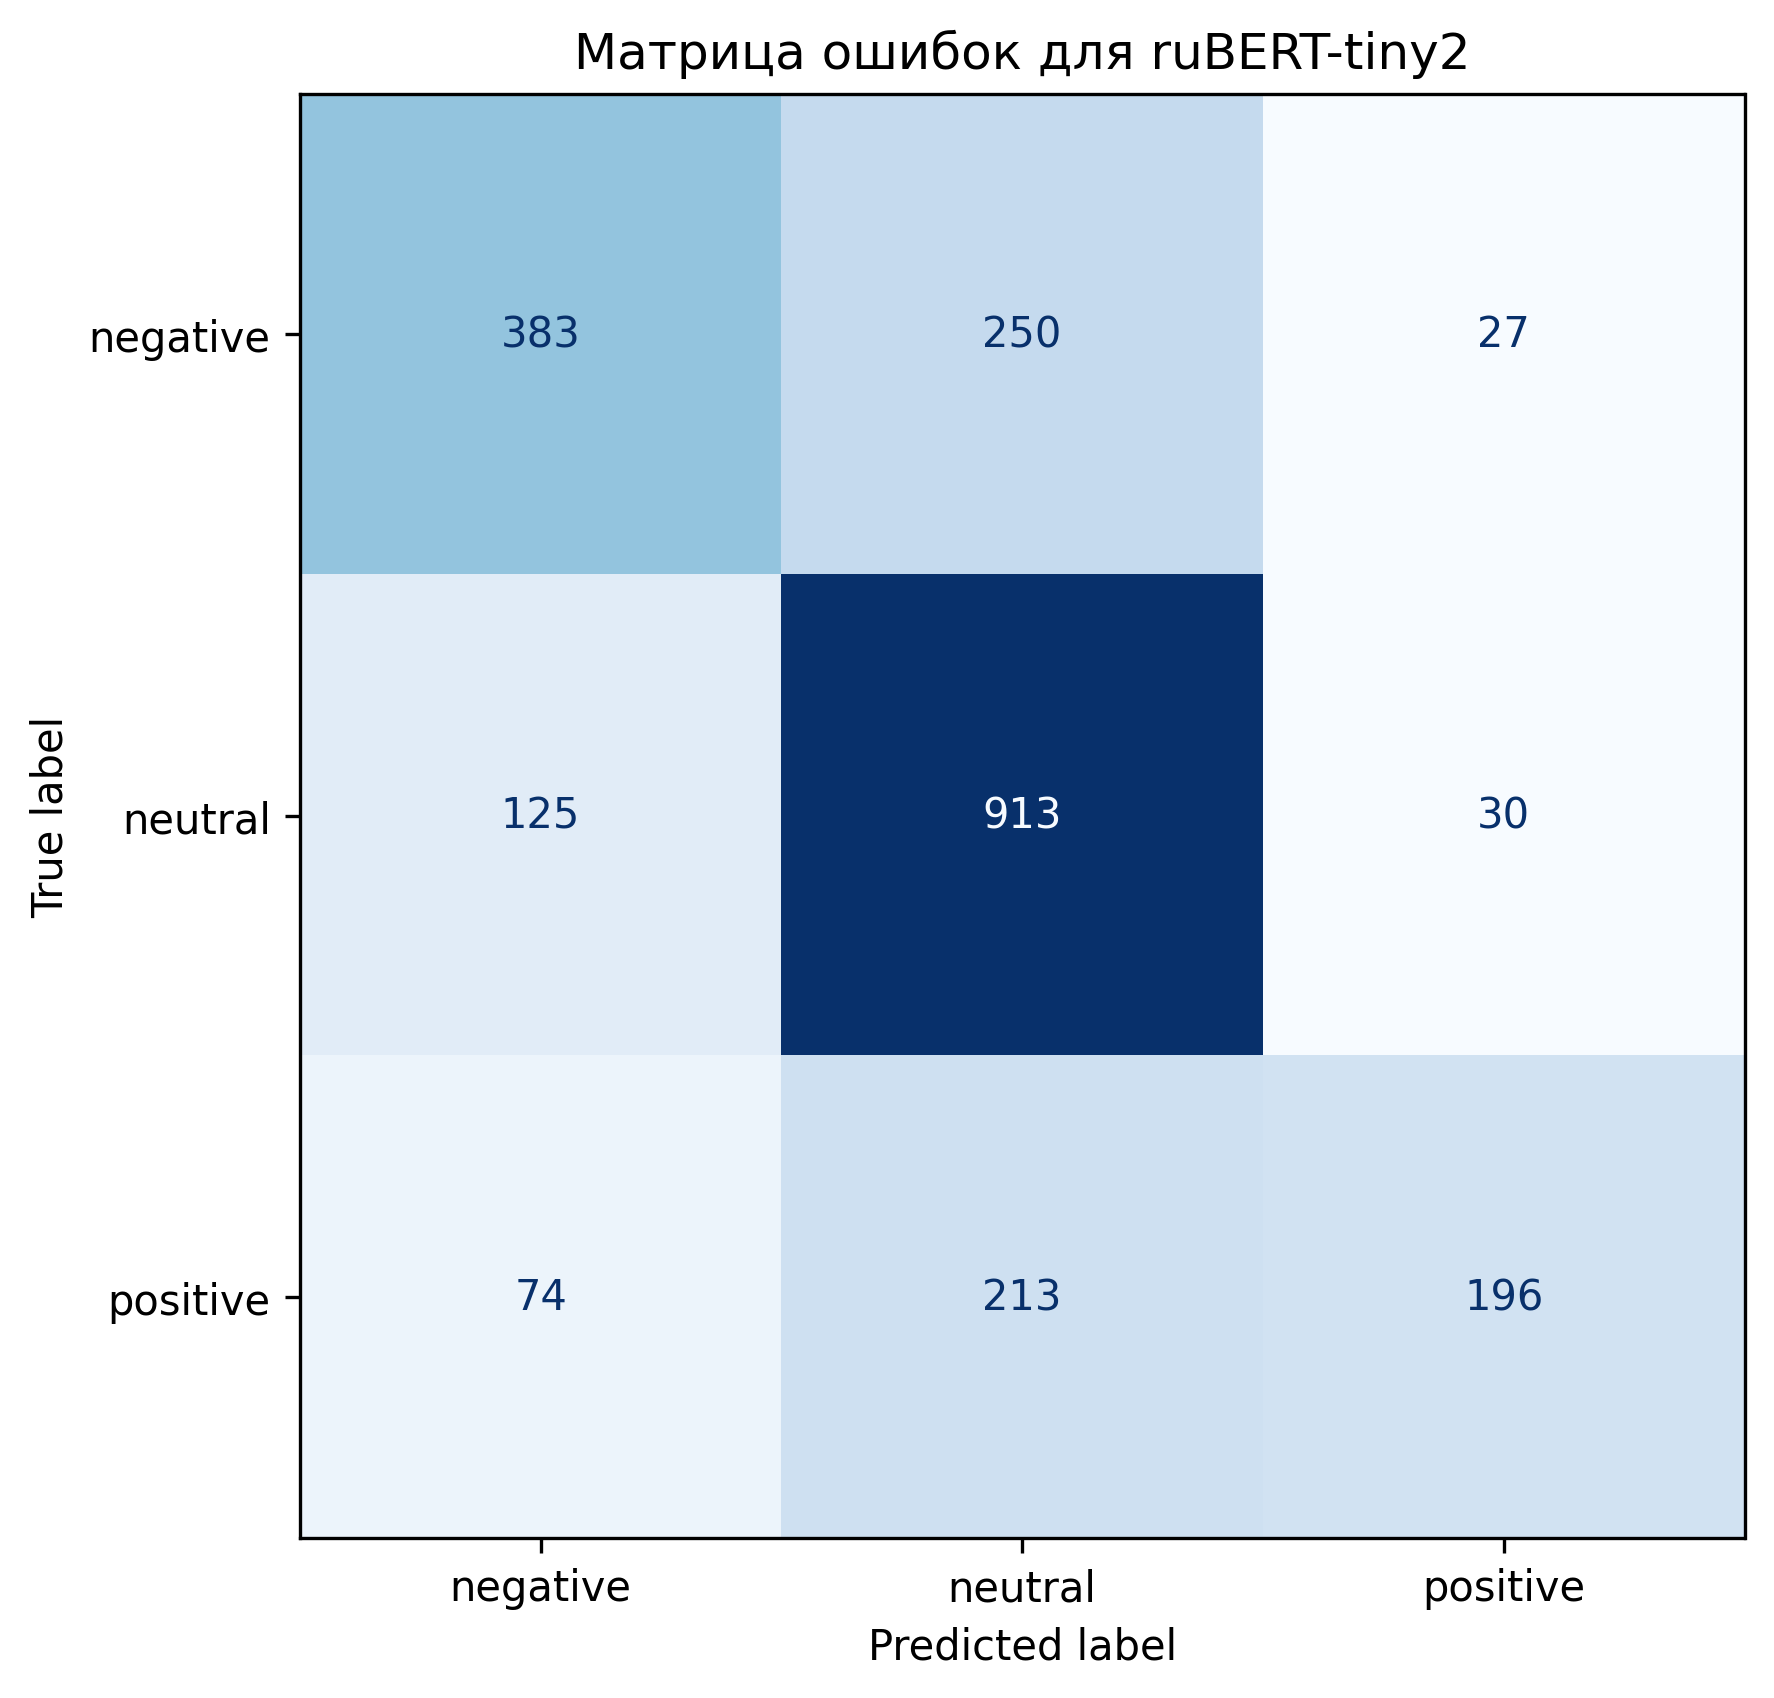

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bert = confusion_matrix(y_true_bert, y_pred_bert, labels=[0, 1, 2])

disp_bert = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_rubert_tiny2.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
bert_result = {
    "model": "ruBERT-tiny2",
    "representation": "Tokenizer",
    "accuracy": round(acc_bert, 4),
    "precision_weighted": round(precision_w_bert, 4),
    "recall_weighted": round(recall_w_bert, 4),
    "weighted_f1": round(f1_w_bert, 4),
    "macro_f1": round(f1_macro_bert, 4),
    "train_time_sec": round(train_time_bert, 4),
    "seed": SEED,
    "notes": "transformer baseline"
}

baseline_results_df = pd.concat([baseline_results_df, pd.DataFrame([bert_result])], ignore_index=True)
baseline_results_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(baseline_results_df)

,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,notes
0,ruBERT-tiny2,Tokenizer,0.6748,0.6862,0.6748,0.6613,0.6322,46.0276,42,transformer baseline
1,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1084,42,classical baseline
2,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,0.8411,42,classical baseline
3,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0133,42,classical baseline
4,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0063,42,classical baseline


In [64]:
baseline_results_df.to_csv(TABLE_DIR / "baseline_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "baseline_results.csv")

Saved: e0_artifacts/tables/baseline_results.csv


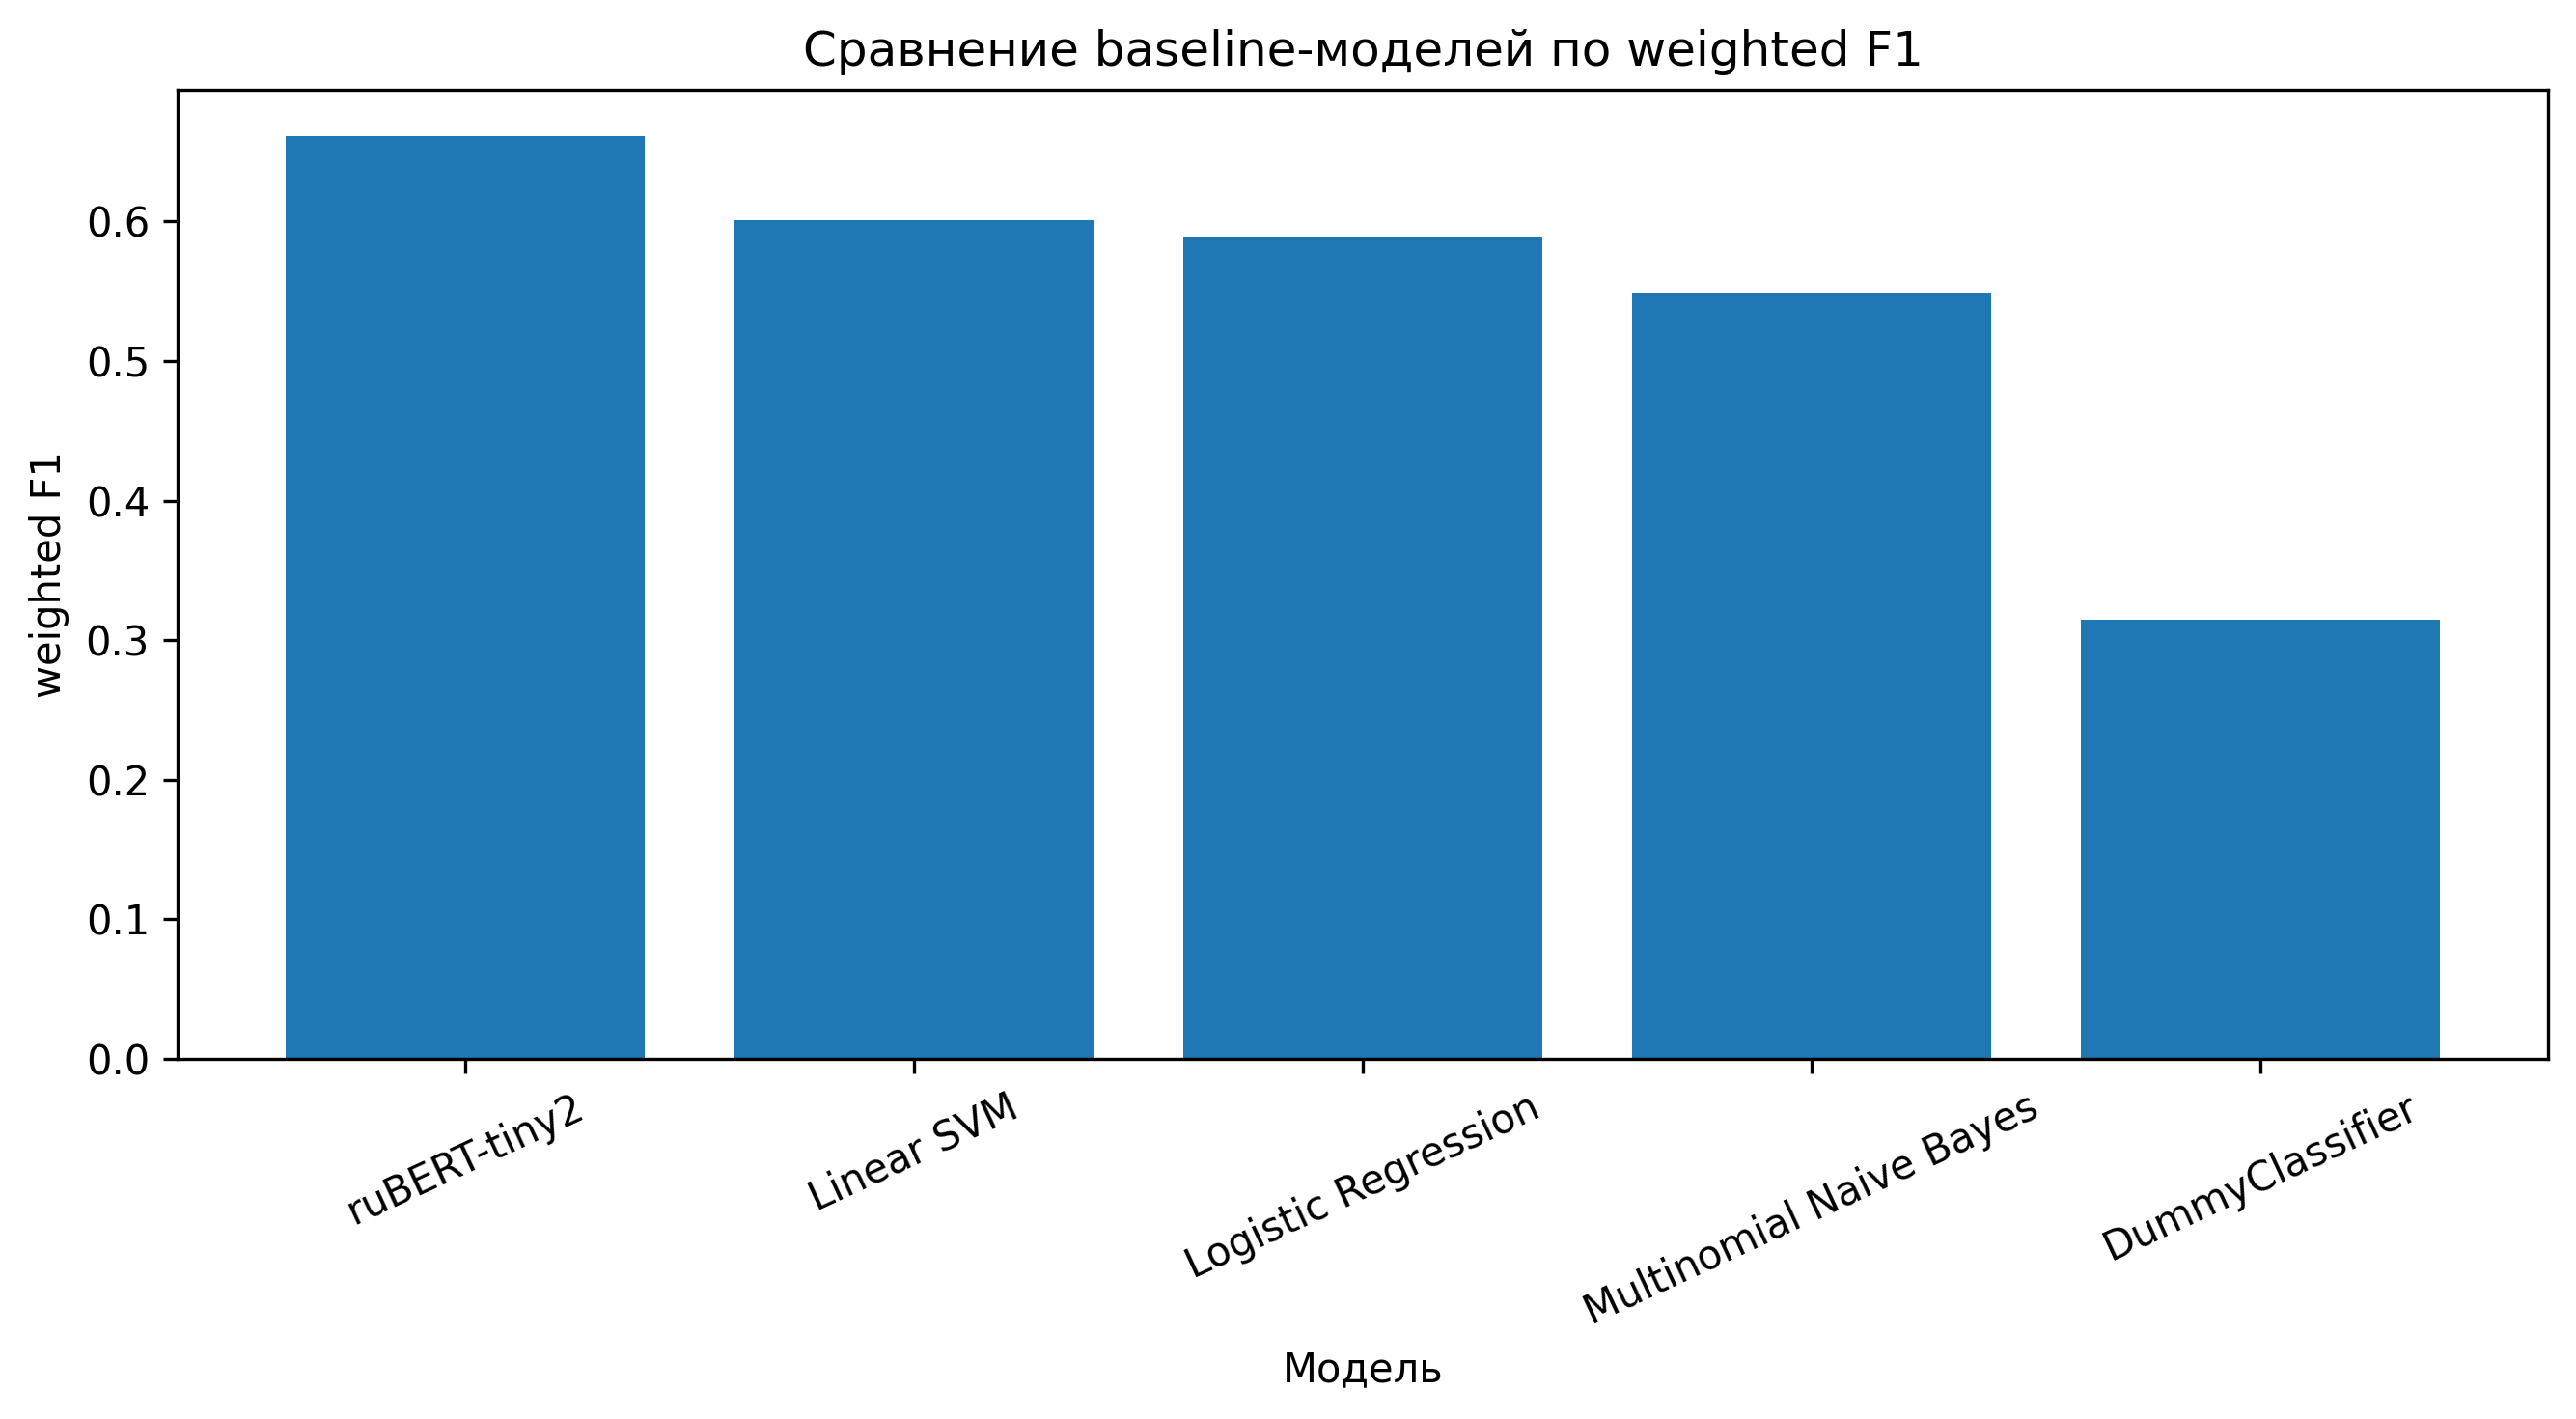

In [65]:
plot_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение baseline-моделей по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

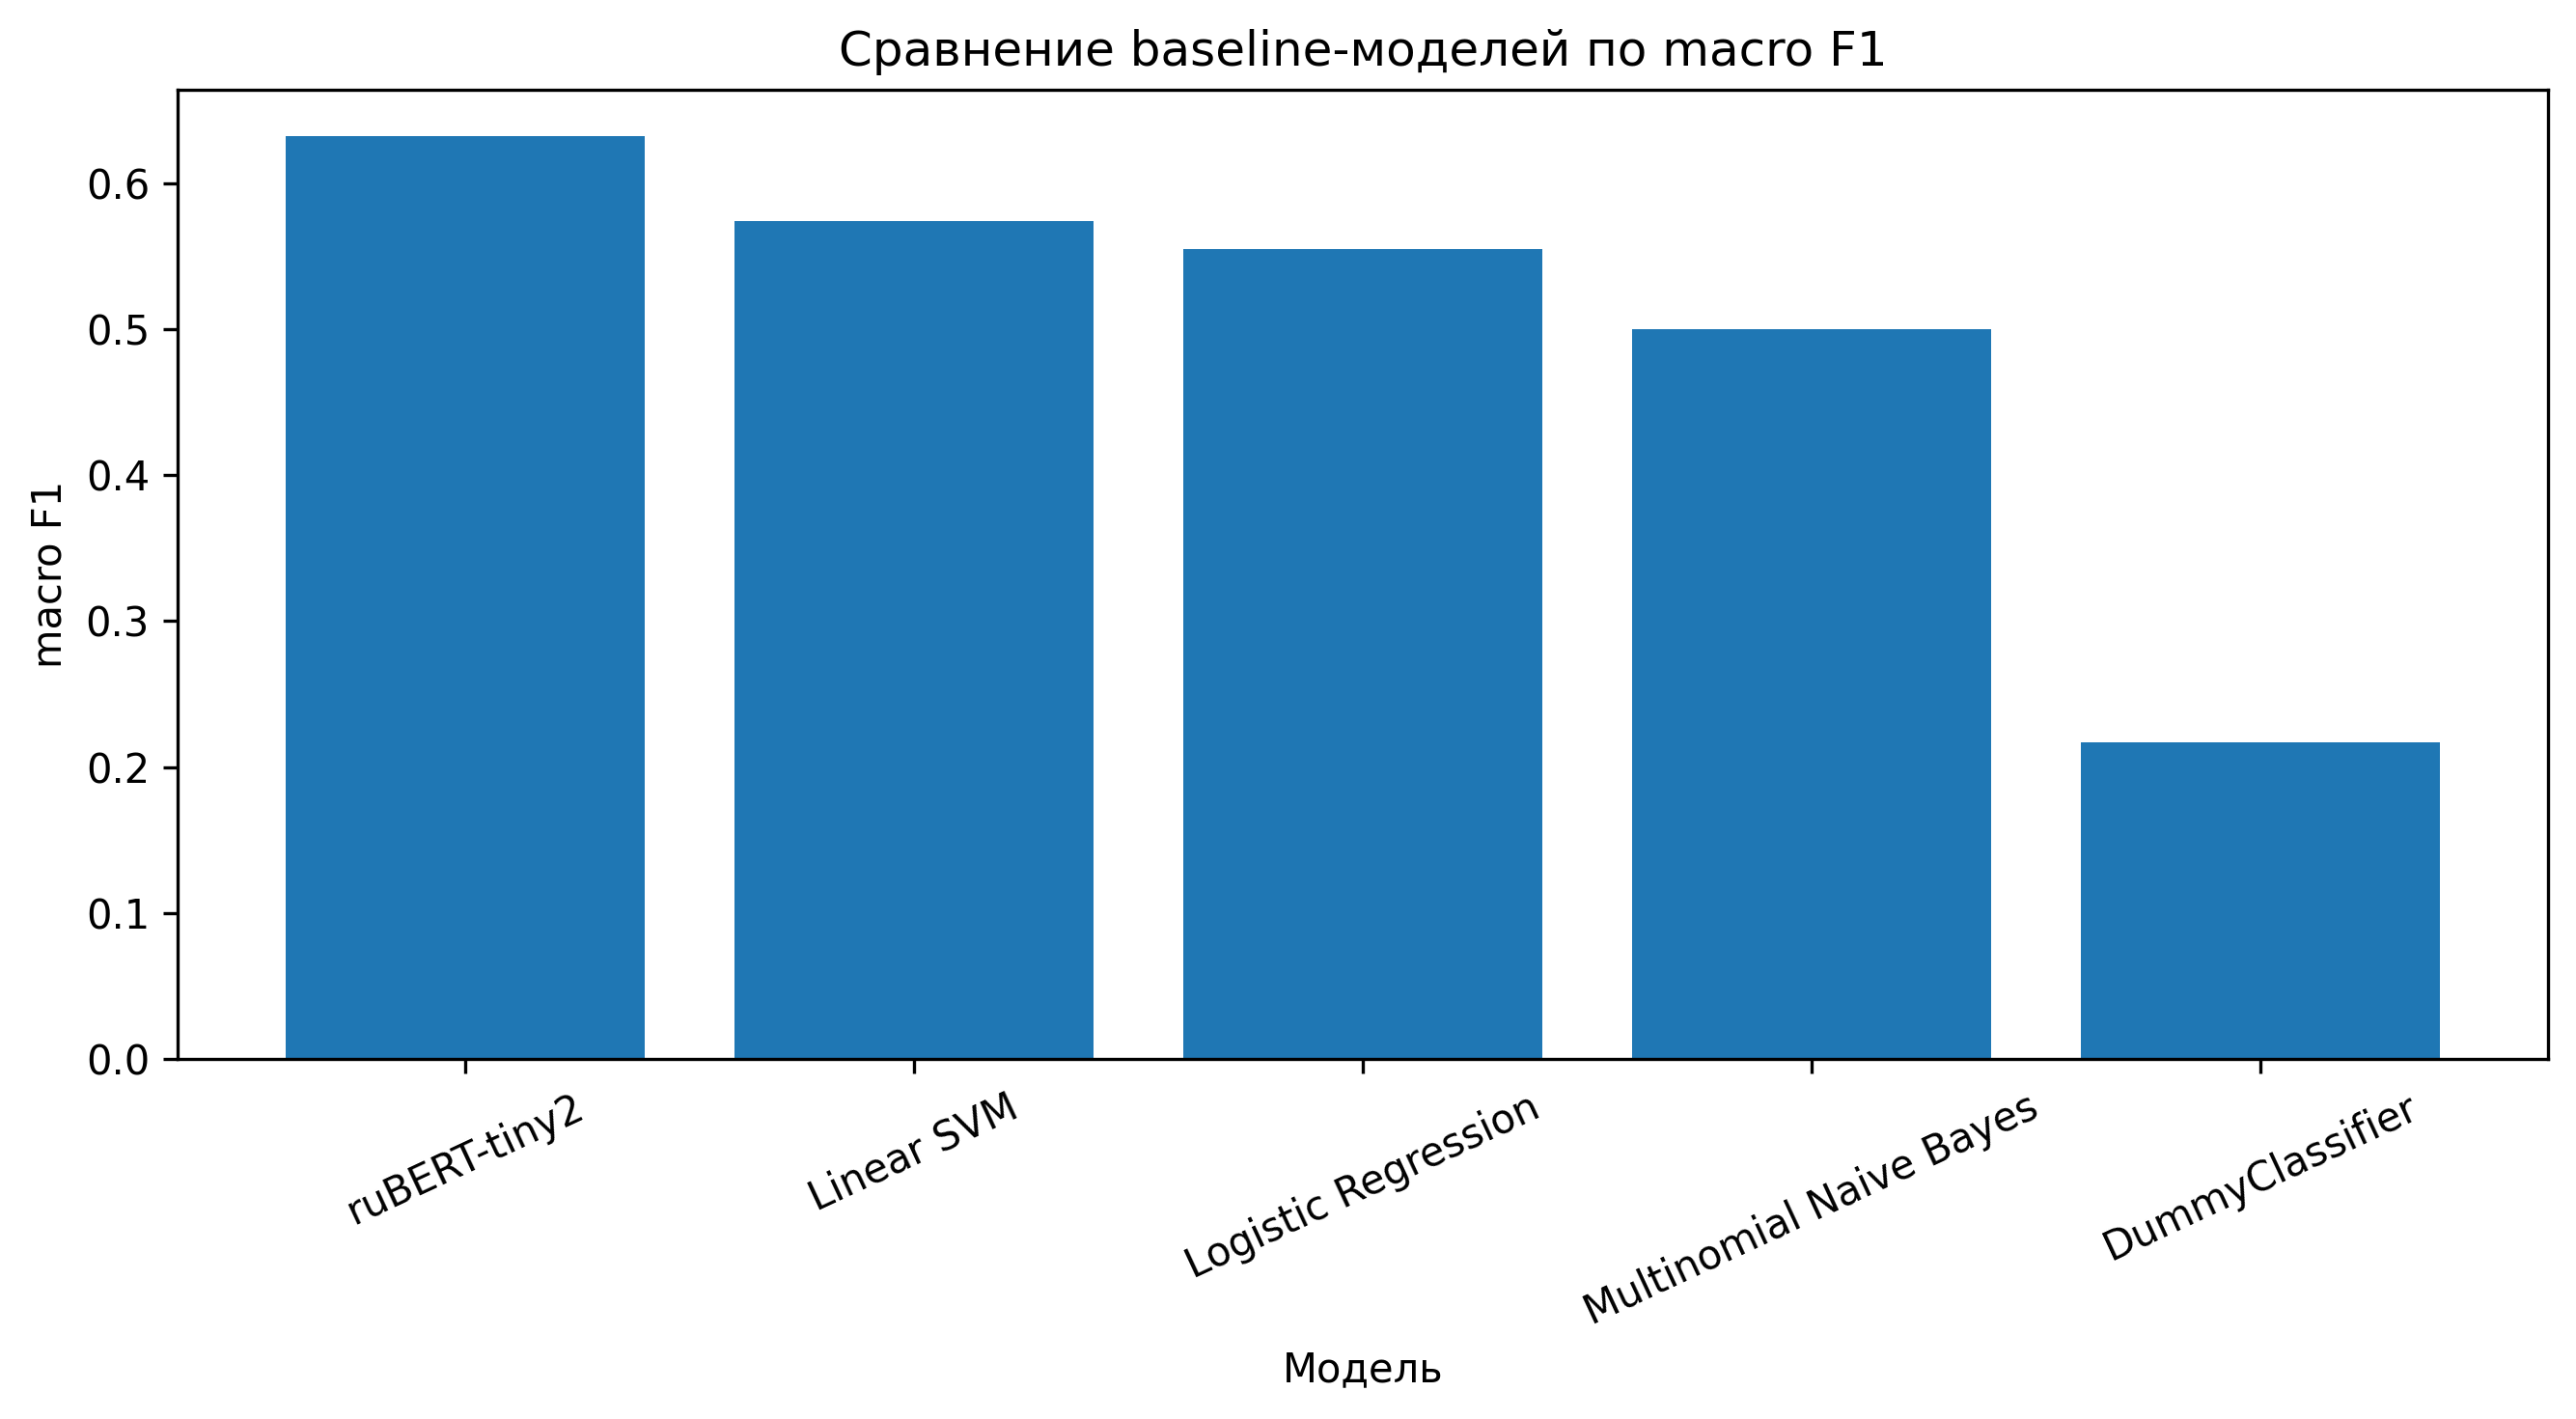

In [66]:
plot_df_macro = baseline_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение baseline-моделей по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
save_path = BERT_DIR / "rubert_tiny2_sentiment_model"
save_path.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(save_path))
tokenizer.save_pretrained(str(save_path))

print("Model saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: e0_artifacts/bert/rubert_tiny2_sentiment_model


In [68]:
bert_baseline_summary = f"""
E0 BERT BASELINE SUMMARY

Model name:
{model_name}

Common config:
{BERT_COMMON_CONFIG}

Baseline training config:
{BERT_BASELINE_CONFIG}

Validation results:
{eval_results_val}

Test results:
accuracy={round(acc_bert, 4)}
precision_weighted={round(precision_w_bert, 4)}
recall_weighted={round(recall_w_bert, 4)}
weighted_f1={round(f1_w_bert, 4)}
macro_f1={round(f1_macro_bert, 4)}

Train time (s):
{round(train_time_bert, 4)}
"""

with open(LOG_DIR / "bert_baseline_summary.txt", "w", encoding="utf-8") as f:
    f.write(bert_baseline_summary)

print("Saved:", LOG_DIR / "bert_baseline_summary.txt")

Saved: e0_artifacts/logs/bert_baseline_summary.txt


## 6. Transformer tuned: ruBERT-tiny2 tuned

In [69]:
from transformers import AutoModelForSequenceClassification

model_v2 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

In [70]:
from transformers import TrainingArguments

training_args_v2 = TrainingArguments(
    output_dir="./rubert_tiny_results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True if device == "cuda" else False
)

In [71]:
from transformers import Trainer

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

In [72]:
import time

start_time = time.time()
trainer_v2.train()
train_time_bert_v2 = time.time() - start_time

print("BERT tuned train time (s):", round(train_time_bert_v2, 4))

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.784152,0.721372,0.685876,0.684849,0.685876,0.682137,0.663559
2,0.676451,0.704209,0.693785,0.692960,0.693785,0.693258,0.679068
3,0.605299,0.708699,0.691525,0.692425,0.691525,0.691838,0.678726


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

BERT tuned train time (s): 53.5373


In [73]:
eval_results_val_v2 = trainer_v2.evaluate(eval_dataset=val_tokenized)
print(eval_results_val_v2)

{'eval_loss': 0.704223096370697, 'eval_accuracy': 0.6949152542372882, 'eval_precision_weighted': 0.6940097404504184, 'eval_recall_weighted': 0.6949152542372882, 'eval_f1_weighted': 0.6943224648432099, 'eval_f1_macro': 0.6801006867492955, 'eval_runtime': 0.5344, 'eval_samples_per_second': 1655.964, 'eval_steps_per_second': 104.784, 'epoch': 3.0}


In [74]:
pred_output_v2 = trainer_v2.predict(test_tokenized)

import numpy as np
y_pred_bert_v2 = np.argmax(pred_output_v2.predictions, axis=-1)
y_true_bert_v2 = pred_output_v2.label_ids

print("Pred shape:", y_pred_bert_v2.shape)
print("True shape:", y_true_bert_v2.shape)

Pred shape: (2211,)
True shape: (2211,)


In [75]:
from sklearn.metrics import classification_report

label_names = ["negative", "neutral", "positive"]

report_bert_v2 = classification_report(
    y_true_bert_v2,
    y_pred_bert_v2,
    target_names=label_names,
    digits=4
)

print(report_bert_v2)

with open(REPORT_DIR / "classification_report_rubert_tiny2_tuned.txt", "w", encoding="utf-8") as f:
    f.write(report_bert_v2)

print("Saved:", REPORT_DIR / "classification_report_rubert_tiny2_tuned.txt")

              precision    recall  f1-score   support

    negative     0.6559    0.6470    0.6514       660
     neutral     0.7286    0.7640    0.7459      1068
    positive     0.6773    0.6170    0.6457       483

    accuracy                         0.6970      2211
   macro avg     0.6873    0.6760    0.6810      2211
weighted avg     0.6957    0.6970    0.6958      2211

Saved: e0_artifacts/reports/classification_report_rubert_tiny2_tuned.txt


In [76]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

acc_bert_v2 = accuracy_score(y_true_bert_v2, y_pred_bert_v2)
precision_w_bert_v2, recall_w_bert_v2, f1_w_bert_v2, _ = precision_recall_fscore_support(
    y_true_bert_v2, y_pred_bert_v2, average="weighted", zero_division=0
)
f1_macro_bert_v2 = f1_score(y_true_bert_v2, y_pred_bert_v2, average="macro")

print("Test accuracy:", round(acc_bert_v2, 4))
print("Test precision_weighted:", round(precision_w_bert_v2, 4))
print("Test recall_weighted:", round(recall_w_bert_v2, 4))
print("Test weighted_f1:", round(f1_w_bert_v2, 4))
print("Test macro_f1:", round(f1_macro_bert_v2, 4))

Test accuracy: 0.697
Test precision_weighted: 0.6957
Test recall_weighted: 0.697
Test weighted_f1: 0.6958
Test macro_f1: 0.681


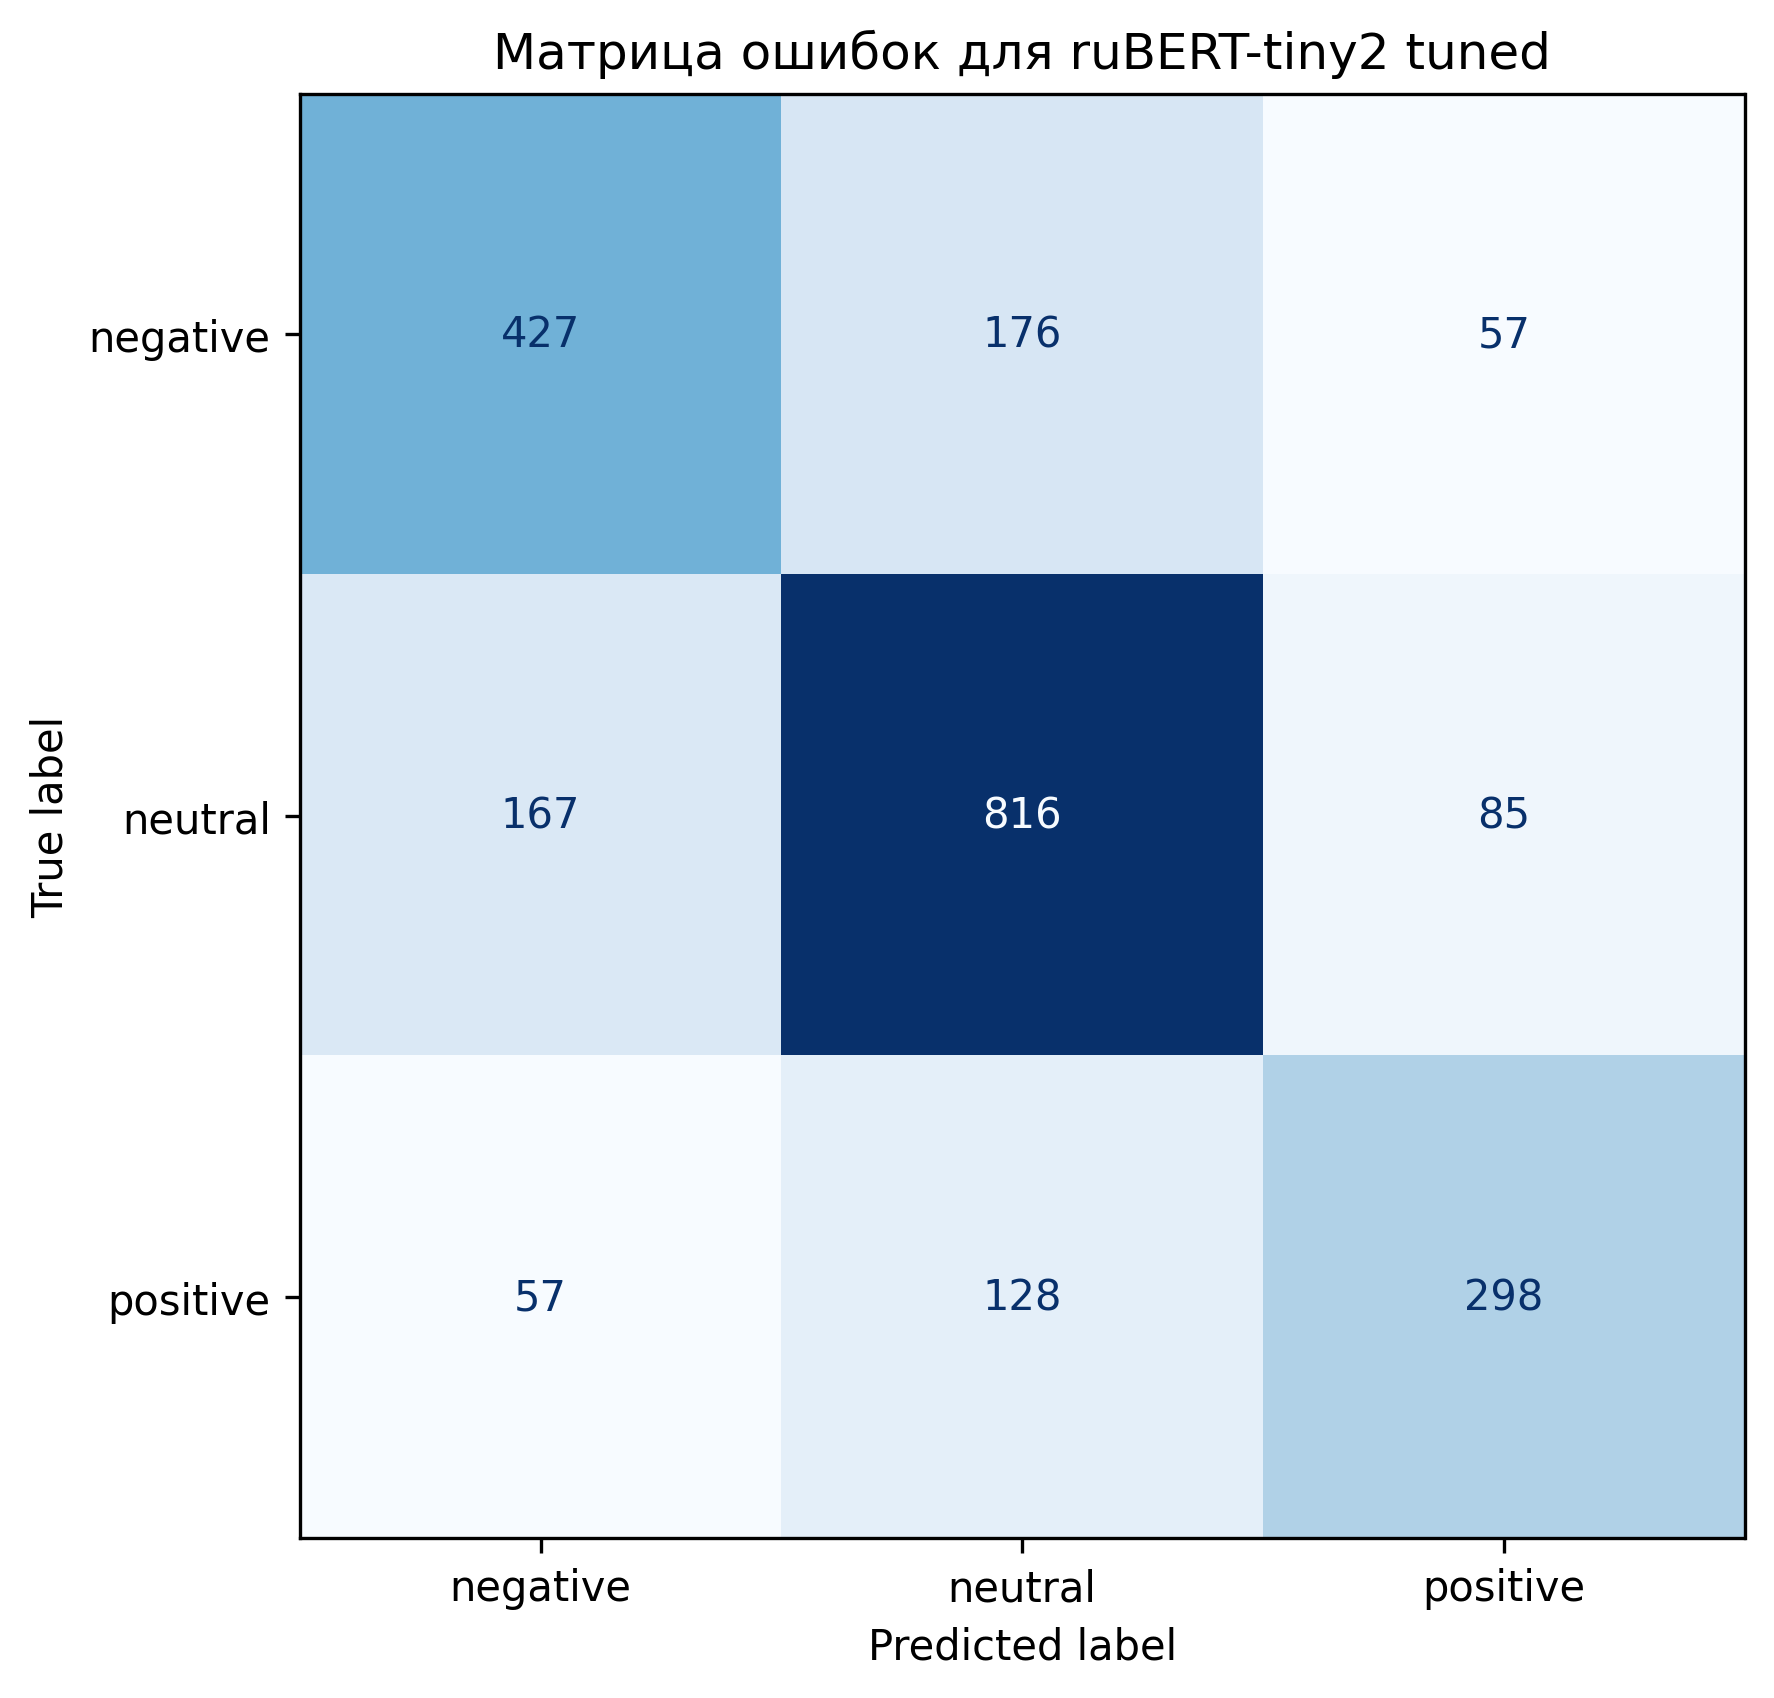

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bert_v2 = confusion_matrix(y_true_bert_v2, y_pred_bert_v2, labels=[0, 1, 2])

disp_bert_v2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert_v2,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert_v2.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2 tuned")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_rubert_tiny2_tuned.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
bert_v2_result = {
    "model": "ruBERT-tiny2 tuned",
    "representation": "Tokenizer",
    "accuracy": round(acc_bert_v2, 4),
    "precision_weighted": round(precision_w_bert_v2, 4),
    "recall_weighted": round(recall_w_bert_v2, 4),
    "weighted_f1": round(f1_w_bert_v2, 4),
    "macro_f1": round(f1_macro_bert_v2, 4),
    "train_time_sec": round(train_time_bert_v2, 4),
    "seed": SEED,
    "notes": "transformer tuned"
}

baseline_results_df = pd.concat([baseline_results_df, pd.DataFrame([bert_v2_result])], ignore_index=True)
baseline_results_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(baseline_results_df)

,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,notes
0,ruBERT-tiny2 tuned,Tokenizer,0.6970,0.6957,0.6970,0.6958,0.6810,53.5373,42,transformer tuned
1,ruBERT-tiny2,Tokenizer,0.6748,0.6862,0.6748,0.6613,0.6322,46.0276,42,transformer baseline
2,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1084,42,classical baseline
3,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,0.8411,42,classical baseline
4,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0133,42,classical baseline
5,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0063,42,classical baseline


In [79]:
baseline_results_df.to_csv(TABLE_DIR / "baseline_results.csv", index=False, encoding="utf-8-sig")
baseline_results_df.to_csv(TABLE_DIR / "final_results_table.csv", index=False, encoding="utf-8-sig")

print("Saved:", TABLE_DIR / "baseline_results.csv")
print("Saved:", TABLE_DIR / "final_results_table.csv")

Saved: e0_artifacts/tables/baseline_results.csv
Saved: e0_artifacts/tables/final_results_table.csv


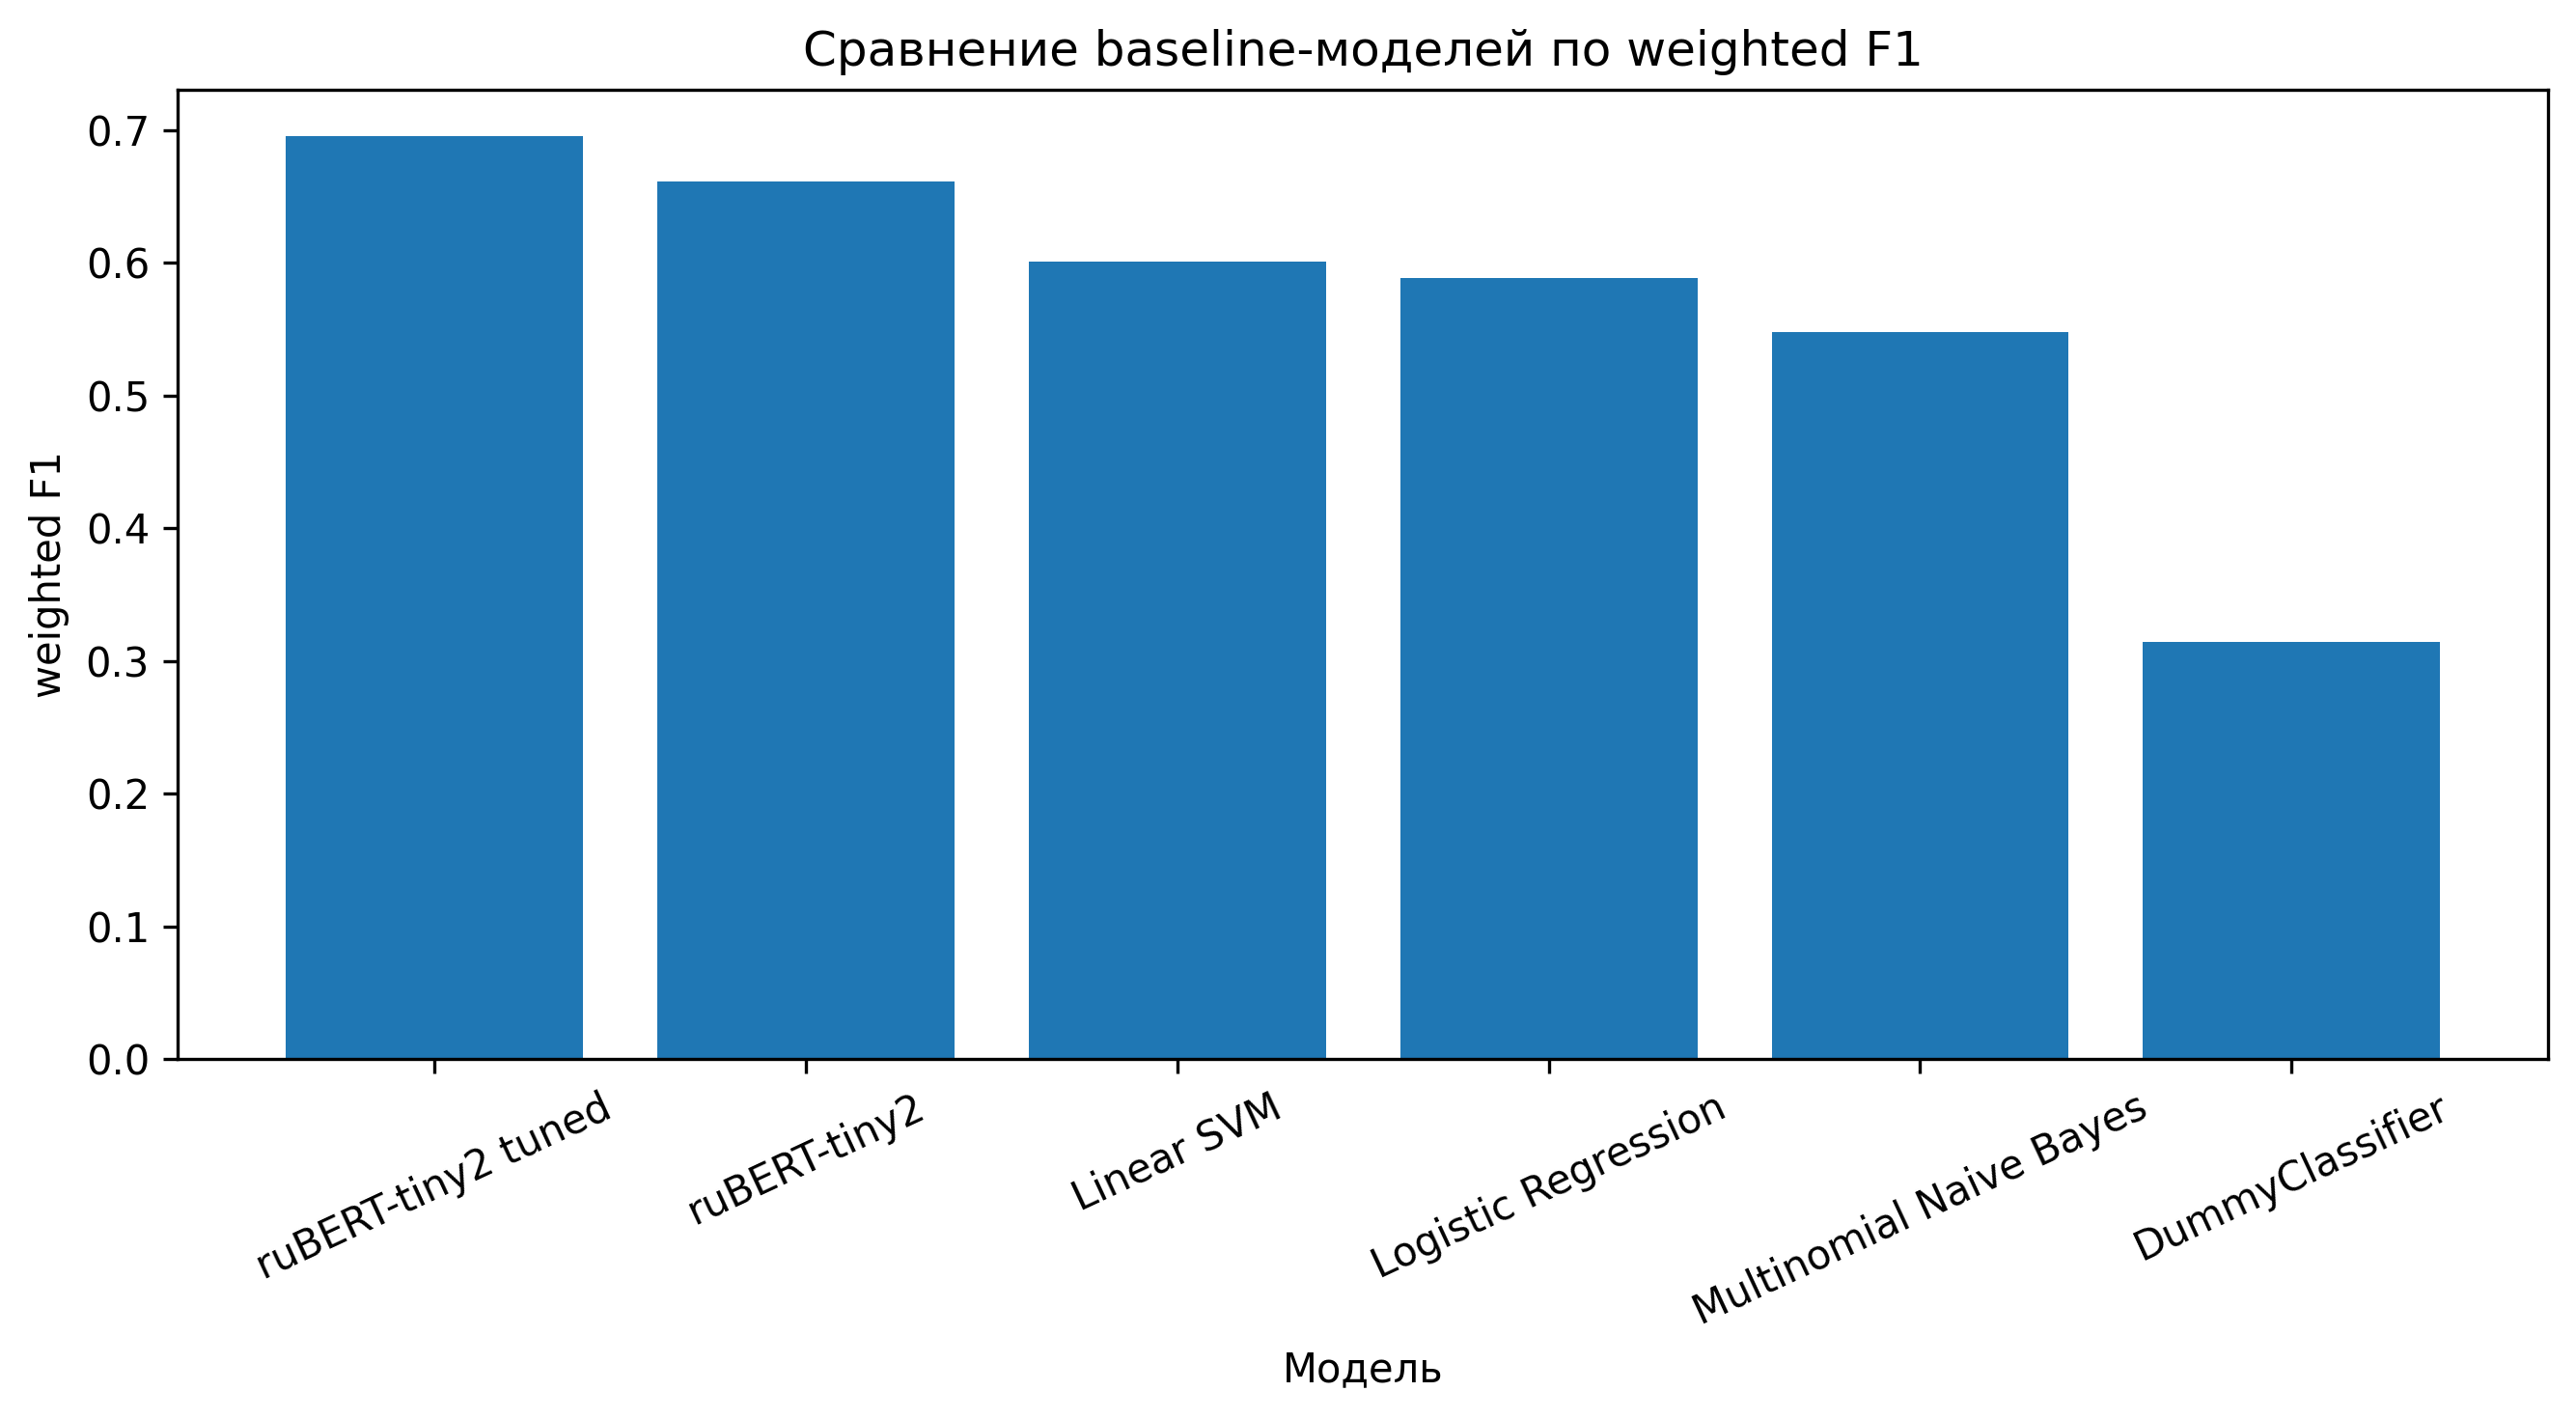

In [80]:
plot_df = baseline_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение baseline-моделей по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

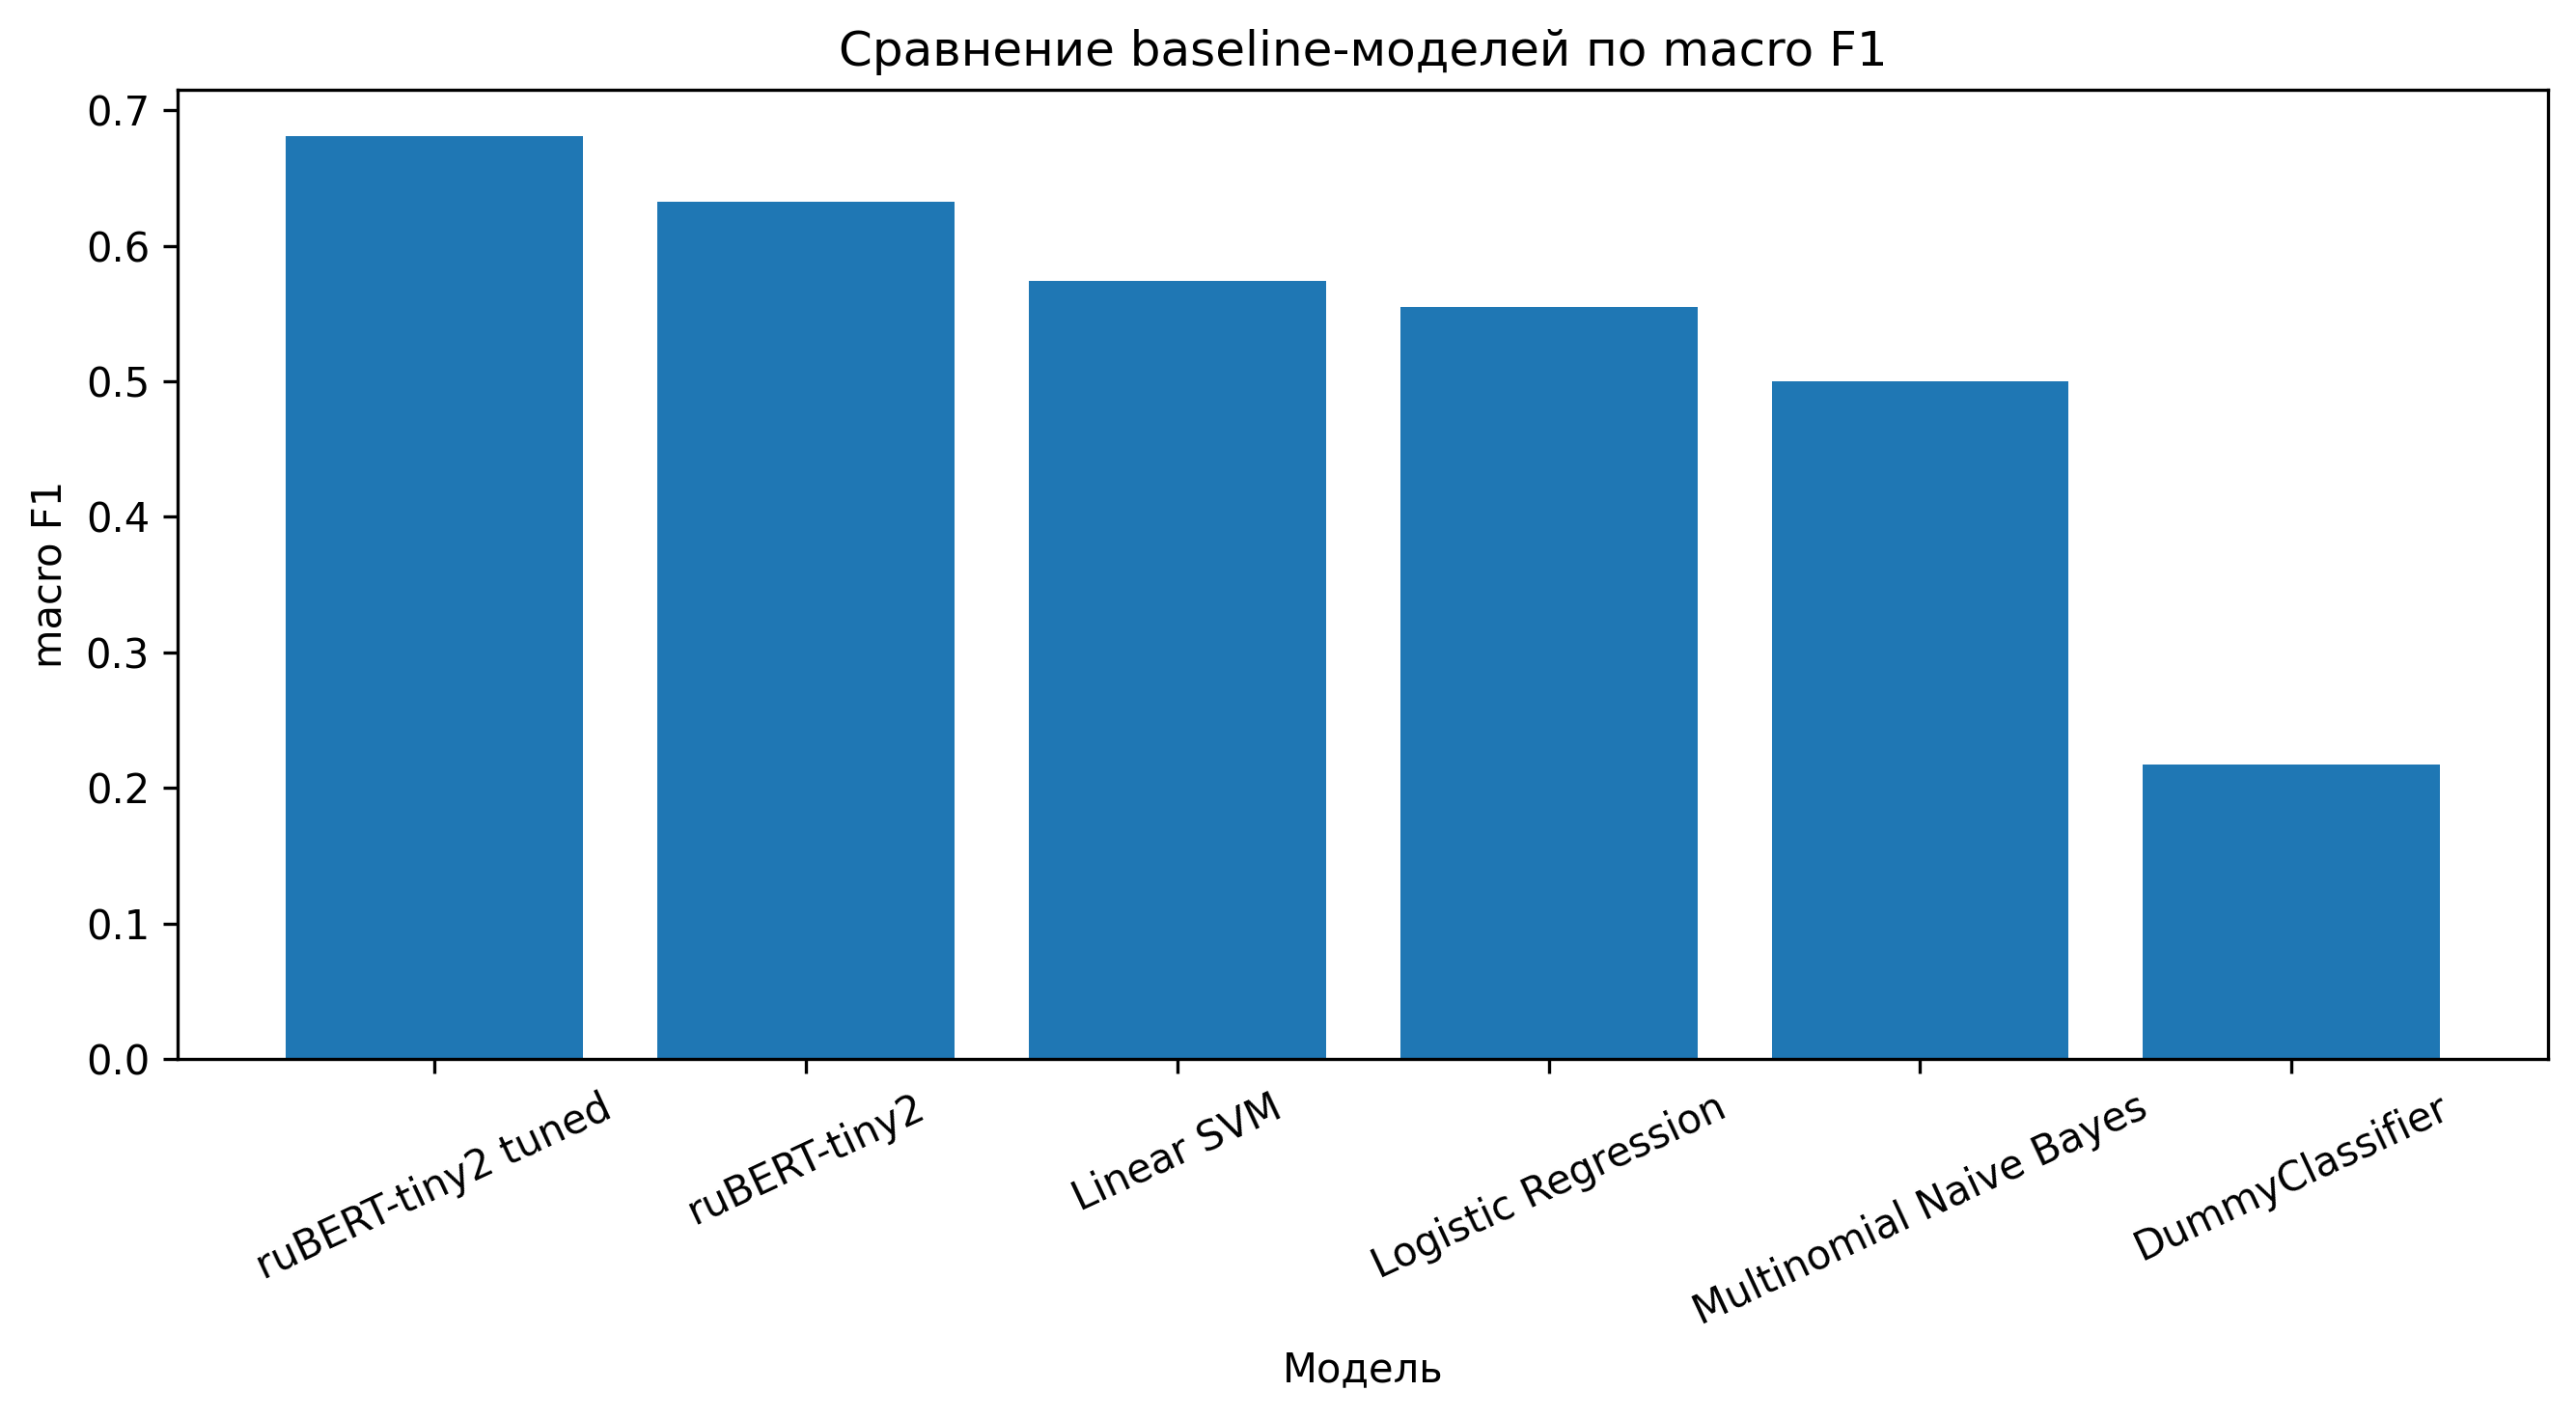

In [81]:
plot_df_macro = baseline_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение baseline-моделей по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_models_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
save_path_v2 = BERT_DIR / "rubert_tiny2_sentiment_model_tuned"
save_path_v2.mkdir(parents=True, exist_ok=True)

trainer_v2.save_model(str(save_path_v2))
tokenizer.save_pretrained(str(save_path_v2))

print("Model saved to:", save_path_v2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: e0_artifacts/bert/rubert_tiny2_sentiment_model_tuned


In [83]:
bert_tuned_summary = f"""
E0 BERT TUNED SUMMARY

Model name:
{model_name}

Common config:
{BERT_COMMON_CONFIG}

Tuned training config:
{BERT_TUNED_CONFIG}

Validation results:
{eval_results_val_v2}

Test results:
accuracy={round(acc_bert_v2, 4)}
precision_weighted={round(precision_w_bert_v2, 4)}
recall_weighted={round(recall_w_bert_v2, 4)}
weighted_f1={round(f1_w_bert_v2, 4)}
macro_f1={round(f1_macro_bert_v2, 4)}

Train time (s):
{round(train_time_bert_v2, 4)}
"""

with open(LOG_DIR / "bert_tuned_summary.txt", "w", encoding="utf-8") as f:
    f.write(bert_tuned_summary)

print("Saved:", LOG_DIR / "bert_tuned_summary.txt")

Saved: e0_artifacts/logs/bert_tuned_summary.txt


## 7. BERT-материалы для ВКР: график по эпохам, torchinfo, Netron

In [84]:
log_history_v2 = trainer_v2.state.log_history
log_history_v2[:5]

[{'loss': 1.0271424865722656,
  'grad_norm': 1.5869389772415161,
  'learning_rate': 2.8012048192771082e-05,
  'epoch': 0.20080321285140562,
  'step': 100},
 {'loss': 0.9272203063964843,
  'grad_norm': 3.223745107650757,
  'learning_rate': 2.6004016064257028e-05,
  'epoch': 0.40160642570281124,
  'step': 200},
 {'loss': 0.8517201995849609,
  'grad_norm': 5.164689064025879,
  'learning_rate': 2.399598393574297e-05,
  'epoch': 0.6024096385542169,
  'step': 300},
 {'loss': 0.7841521453857422,
  'grad_norm': 9.250907897949219,
  'learning_rate': 2.1987951807228917e-05,
  'epoch': 0.8032128514056225,
  'step': 400},
 {'eval_loss': 0.7213717103004456,
  'eval_accuracy': 0.6858757062146893,
  'eval_precision_weighted': 0.6848491795146919,
  'eval_recall_weighted': 0.6858757062146893,
  'eval_f1_weighted': 0.6821374972837227,
  'eval_f1_macro': 0.6635593055863946,
  'eval_runtime': 0.6297,
  'eval_samples_per_second': 1405.376,
  'eval_steps_per_second': 88.928,
  'epoch': 1.0,
  'step': 498}]

In [87]:
epoch_to_f1 = {}

for item in trainer_v2.state.log_history:
    if "epoch" in item and "eval_f1_weighted" in item:
        epoch = int(item["epoch"])
        if epoch not in epoch_to_f1:
            epoch_to_f1[epoch] = item["eval_f1_weighted"]

epochs = sorted(epoch_to_f1.keys())
f1_scores = [epoch_to_f1[e] for e in epochs]

print(list(zip(epochs, f1_scores)))

[(1, 0.6821374972837227), (2, 0.6932580813978384), (3, 0.6918383783132649)]


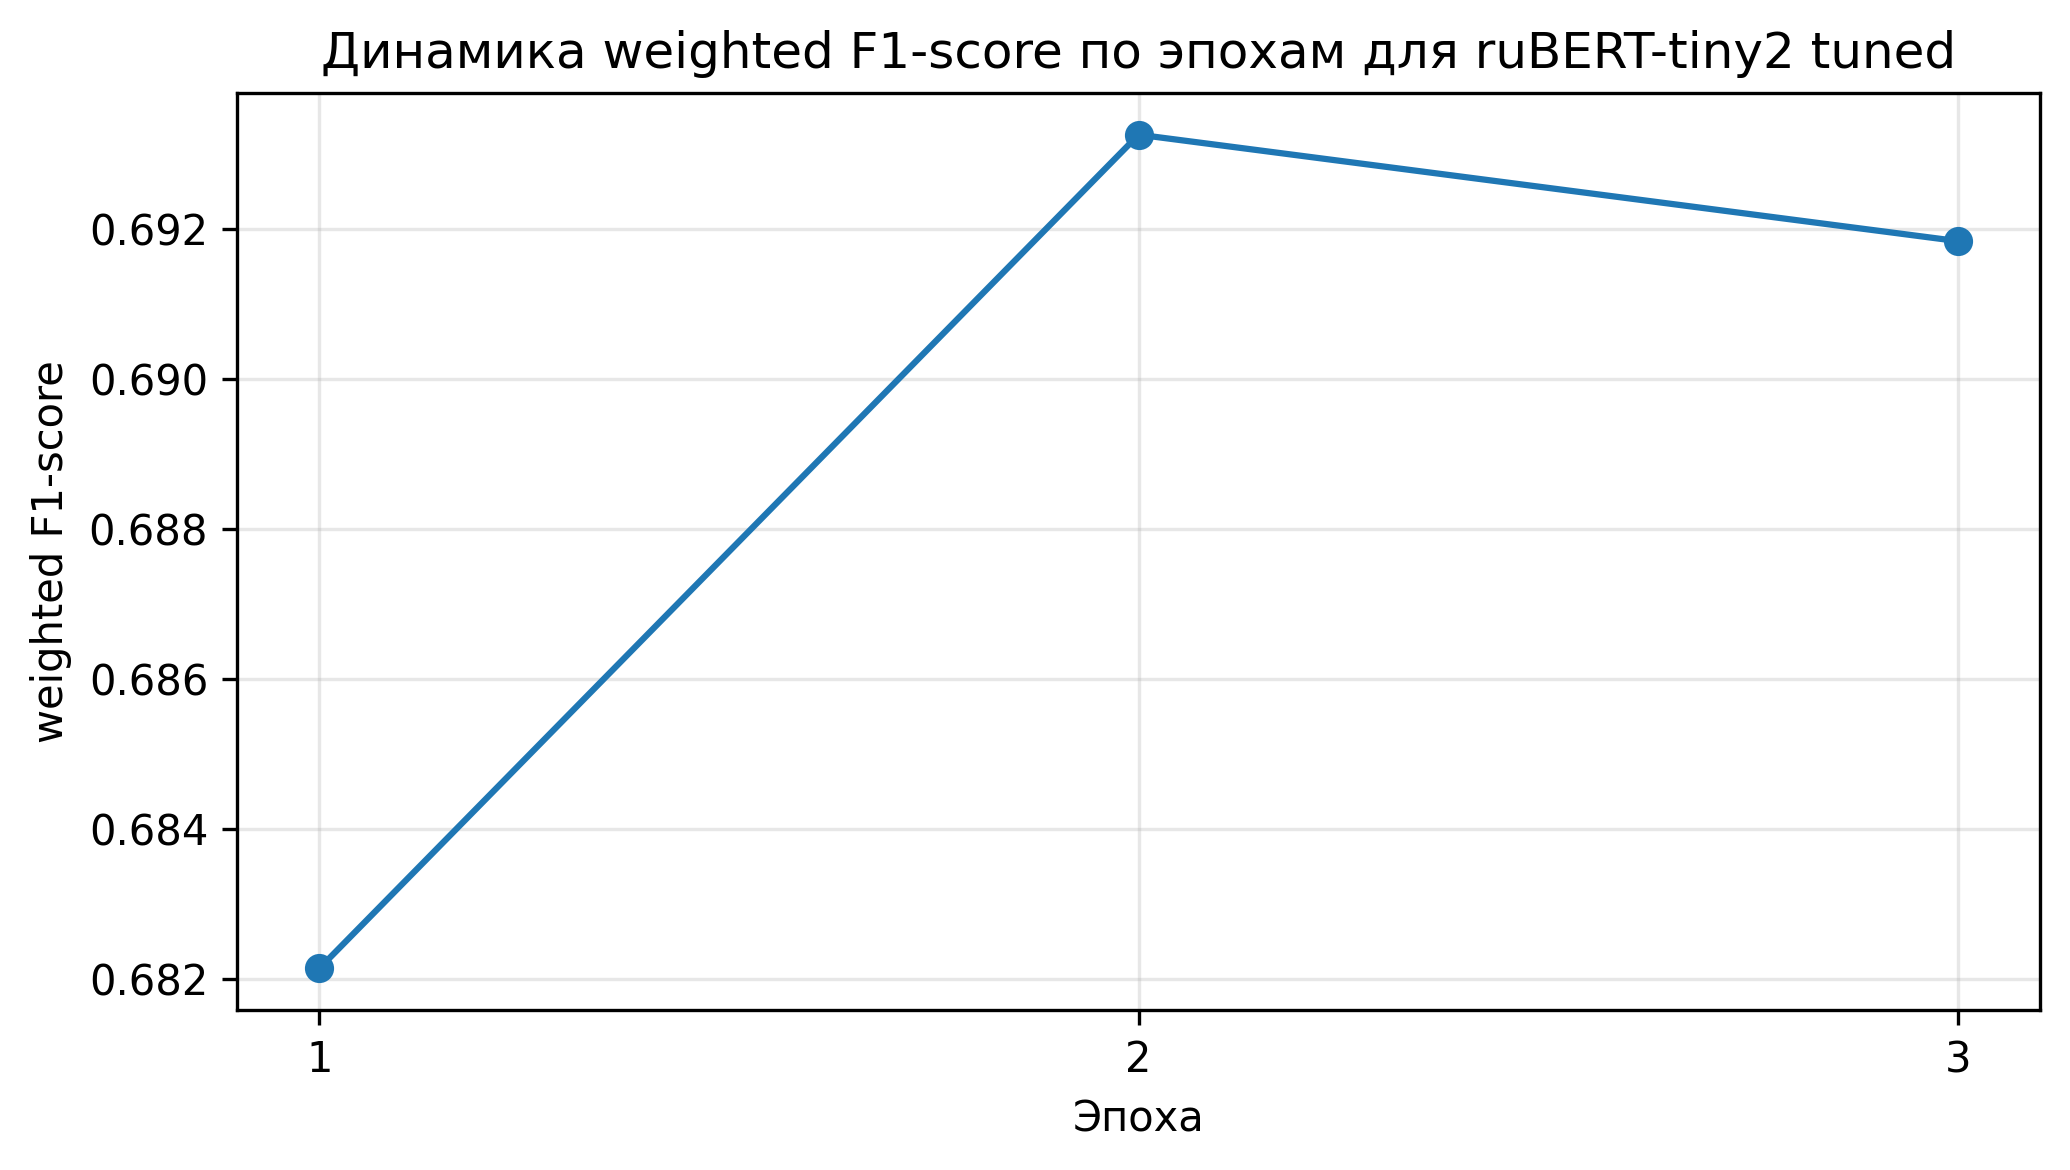

In [88]:
plt.figure(figsize=(7, 4), dpi=300)
plt.plot(epochs, f1_scores, marker="o")
plt.title("Динамика weighted F1-score по эпохам для ruBERT-tiny2 tuned")
plt.xlabel("Эпоха")
plt.ylabel("weighted F1-score")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BERT_DIR / "bert_epochs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [89]:
!pip install -q torchinfo

In [90]:
import torch
from torchinfo import summary

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2.to(torch_device)

sample_input_ids = test_tokenized[0]["input_ids"].unsqueeze(0).to(torch_device)
sample_attention_mask = test_tokenized[0]["attention_mask"].unsqueeze(0).to(torch_device)

In [92]:
summary_output = summary(
    model_v2,
    input_data={
        "input_ids": sample_input_ids,
        "attention_mask": sample_attention_mask
    },
    verbose=0
)

summary_text = str(summary_output)
print(summary_text[:3000])  # чтобы убедиться, что всё вывелось

Layer (type:depth-idx)                                  Output Shape              Param #
BertForSequenceClassification                           [1, 3]                    --
├─BertModel: 1-1                                        [1, 312]                  --
│    └─BertEmbeddings: 2-1                              [1, 128, 312]             --
│    │    └─Embedding: 3-1                              [1, 128, 312]             26,154,336
│    │    └─Embedding: 3-2                              [1, 128, 312]             624
│    │    └─Embedding: 3-3                              [1, 128, 312]             638,976
│    │    └─LayerNorm: 3-4                              [1, 128, 312]             624
│    │    └─Dropout: 3-5                                [1, 128, 312]             --
│    └─BertEncoder: 2-2                                 [1, 128, 312]             --
│    │    └─ModuleList: 3-6                             --                        2,301,552
│    └─BertPooler: 2-3                

In [93]:
with open(BERT_DIR / "torchinfo_rubert_tuned.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", BERT_DIR / "torchinfo_rubert_tuned.txt")

Saved: e0_artifacts/bert/torchinfo_rubert_tuned.txt


In [94]:
!pip install -q onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 7.0 MB/s eta 0:00:00


In [95]:
import torch
import torch.nn as nn

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        return self.model(input_ids=input_ids, attention_mask=attention_mask).logits

wrapped_model = WrappedModel(model_v2)
wrapped_model.eval()
wrapped_model.to(torch_device)

dummy_input_ids = test_tokenized[0]["input_ids"].unsqueeze(0).to(torch_device)
dummy_attention_mask = test_tokenized[0]["attention_mask"].unsqueeze(0).to(torch_device)

In [96]:
onnx_path = BERT_DIR / "rubert_tiny2_tuned.onnx"

torch.onnx.export(
    wrapped_model,
    (dummy_input_ids, dummy_attention_mask),
    str(onnx_path),
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "seq_len"},
        "attention_mask": {0: "batch_size", 1: "seq_len"},
        "logits": {0: "batch_size"}
    },
    opset_version=18
)

print("Saved:", onnx_path)

/tmp/ipykernel_908/1566847991.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0423 14:14:03.936000 908 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0423 14:14:03.945000 908 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0423 14:14:03.947000 908 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'floa

[torch.onnx] Obtain model graph for `WrappedModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `WrappedModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: seq_len will not be used, since it shares the same shape constraints with another axis: seq_len.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


Saved: e0_artifacts/bert/rubert_tiny2_tuned.onnx


In [97]:
bert_artifacts_summary = f"""
E0 BERT ARTIFACTS SUMMARY

Saved files:
- {BERT_DIR / "bert_epochs_f1.png"}
- {BERT_DIR / "torchinfo_rubert_tuned.txt"}
- {BERT_DIR / "rubert_tiny2_tuned.onnx"}

Model:
{model_name}

Torch device:
{torch_device}

Epoch weighted F1 values:
{epoch_f1}

Note:
The ONNX file is intended for visualization in Netron.
After downloading it locally, open it in Netron and save screenshots
for the top and bottom parts of the architecture graph.
"""

with open(LOG_DIR / "bert_artifacts_summary.txt", "w", encoding="utf-8") as f:
    f.write(bert_artifacts_summary)

print("Saved:", LOG_DIR / "bert_artifacts_summary.txt")

Saved: e0_artifacts/logs/bert_artifacts_summary.txt


## 8. Финальная упаковка эксперимента E0

In [98]:
experiment_registry = baseline_results_df.copy()

experiment_registry.insert(0, "experiment_id", [
    "E0-bert-tuned",
    "E0-bert-base",
    "E0-svm",
    "E0-logreg",
    "E0-mnb",
    "E0-dummy"
])

experiment_registry["dataset"] = "RuSentiTweet"
experiment_registry["train_split"] = "train_final"
experiment_registry["val_split"] = "val_final"
experiment_registry["test_split"] = "test_final"
experiment_registry["status"] = "completed"

display(experiment_registry)

,experiment_id,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,notes,dataset,train_split,val_split,test_split,status
0,E0-bert-tuned,ruBERT-tiny2 tuned,Tokenizer,0.6970,0.6957,0.6970,0.6958,0.6810,53.5373,42,transformer tuned,RuSentiTweet,train_final,val_final,test_final,completed
1,E0-bert-base,ruBERT-tiny2,Tokenizer,0.6748,0.6862,0.6748,0.6613,0.6322,46.0276,42,transformer baseline,RuSentiTweet,train_final,val_final,test_final,completed
2,E0-svm,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1084,42,classical baseline,RuSentiTweet,train_final,val_final,test_final,completed
3,E0-logreg,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,0.8411,42,classical baseline,RuSentiTweet,train_final,val_final,test_final,completed
4,E0-mnb,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0133,42,classical baseline,RuSentiTweet,train_final,val_final,test_final,completed
5,E0-dummy,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0063,42,classical baseline,RuSentiTweet,train_final,val_final,test_final,completed


In [99]:
experiment_registry.to_csv(TABLE_DIR / "experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "experiment_registry.csv")

Saved: e0_artifacts/tables/experiment_registry.csv


In [100]:
best_model_row = baseline_results_df.iloc[0]
best_classical_row = baseline_results_df[baseline_results_df["notes"].str.contains("classical", case=False)].iloc[0]

e0_final_summary = f"""
E0 FINAL SUMMARY

Goal:
Reproduce and formalize the baseline experiments for sentiment classification
of Russian short texts.

Dataset:
RuSentiTweet

Target classes:
negative / neutral / positive

Filtered dataset sizes:
train_df = {train_df.shape}
train_final_df = {train_final_df.shape}
val_final_df = {val_final_df.shape}
test_df = {test_df.shape}

Removed classes:
skip, speech

Best overall model:
{best_model_row["model"]}
accuracy = {best_model_row["accuracy"]}
weighted_f1 = {best_model_row["weighted_f1"]}
macro_f1 = {best_model_row["macro_f1"]}

Best classical model:
{best_classical_row["model"]}
accuracy = {best_classical_row["accuracy"]}
weighted_f1 = {best_classical_row["weighted_f1"]}
macro_f1 = {best_classical_row["macro_f1"]}

Final ranking:
{baseline_results_df[["model", "accuracy", "weighted_f1", "macro_f1"]].to_string(index=False)}

Artifacts prepared:
- cleaned train/test files
- split description
- preprocessing configs
- classical reports
- BERT reports
- confusion matrices
- model comparison charts
- torchinfo
- ONNX for Netron
- Netron screenshots

Note:
BERT experiments in E0 were run with a correct train/validation/test scheme:
validation was used inside Trainer, and test was used only for final evaluation.
"""

with open(LOG_DIR / "e0_final_summary.txt", "w", encoding="utf-8") as f:
    f.write(e0_final_summary)

print("Saved:", LOG_DIR / "e0_final_summary.txt")

Saved: e0_artifacts/logs/e0_final_summary.txt


In [101]:
from pathlib import Path

all_files = sorted([str(p) for p in BASE_DIR.rglob("*") if p.is_file()])

manifest_text = "E0 ARTIFACTS MANIFEST\n\n" + "\n".join(all_files)

with open(LOG_DIR / "e0_artifacts_manifest.txt", "w", encoding="utf-8") as f:
    f.write(manifest_text)

print("Saved:", LOG_DIR / "e0_artifacts_manifest.txt")
print("\nTotal files:", len(all_files))

Saved: e0_artifacts/logs/e0_artifacts_manifest.txt

Total files: 52


In [102]:
baseline_results_df.to_csv(TABLE_DIR / "baseline_results.csv", index=False, encoding="utf-8-sig")
baseline_results_df.to_csv(TABLE_DIR / "final_results_table.csv", index=False, encoding="utf-8-sig")
experiment_registry.to_csv(TABLE_DIR / "experiment_registry.csv", index=False, encoding="utf-8-sig")

print("Main E0 tables re-saved successfully.")

Main E0 tables re-saved successfully.
